In [1]:
# ============================================================
# IMPORTS ET CONFIGURATION
# ============================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

# Modèles
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)

# Métriques
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.preprocessing import label_binarize

# XGBoost et LightGBM
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost disponible")
except ImportError:
    HAS_XGB = False
    print("XGBoost non disponible — pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
    print("LightGBM disponible")
except ImportError:
    HAS_LGBM = False
    print("LightGBM non disponible — pip install lightgbm")

# Configuration générale
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
CV_FOLDS     = 5



XGBoost disponible
LightGBM disponible


In [2]:
# Recherche robuste du dossier contenant les fichiers processed
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "heart_disease",
    Path.cwd().parent / "heart_disease",
]

files = {
    "cleveland": "processed.cleveland.data",
    "hungarian": "processed.hungarian.data",
    "switzerland": "processed.switzerland.data",
    "va": "processed.va.data",
}

DATA_DIR = None
for directory in candidate_dirs:
    if all((directory / filename).exists() for filename in files.values()):
        DATA_DIR = directory
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Impossible de trouver les fichiers processed. "
        "Placez-les dans le dossier courant ou dans un sous-dossier 'data'."
    )

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "num"
]

dfs = []
for source, filename in files.items():
    df_source = pd.read_csv(
        DATA_DIR / filename,
        header=None,
        names=column_names,
        na_values="?"
    )
    df_source["source"] = source
    dfs.append(df_source)

df = pd.concat(dfs, ignore_index=True)

print(f"Dossier utilisé : {DATA_DIR}")
print(f"Dimensions du jeu fusionné : {df.shape}")
display(df.head())



Dossier utilisé : C:\Users\DELL XPS 13\Desktop\Projet_ML2\heart_disease
Dimensions du jeu fusionné : (920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.0000,1.0000,1.0000,145.0000,233.0000,1.0000,2.0000,150.0000,0.0000,2.3000,3.0000,0.0000,6.0000,0,cleveland
1,67.0000,1.0000,4.0000,160.0000,286.0000,0.0000,2.0000,108.0000,1.0000,1.5000,2.0000,3.0000,3.0000,2,cleveland
2,67.0000,1.0000,4.0000,120.0000,229.0000,0.0000,2.0000,129.0000,1.0000,2.6000,2.0000,2.0000,7.0000,1,cleveland
3,37.0000,1.0000,3.0000,130.0000,250.0000,0.0000,0.0000,187.0000,0.0000,3.5000,3.0000,0.0000,3.0000,0,cleveland
4,41.0000,0.0000,2.0000,130.0000,204.0000,0.0000,2.0000,172.0000,0.0000,1.4000,1.0000,0.0000,3.0000,0,cleveland


In [3]:
df.head(50)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.0000,1.0000,1.0000,145.0000,233.0000,1.0000,2.0000,150.0000,0.0000,2.3000,3.0000,0.0000,6.0000,0,cleveland
1,67.0000,1.0000,4.0000,160.0000,286.0000,0.0000,2.0000,108.0000,1.0000,1.5000,2.0000,3.0000,3.0000,2,cleveland
2,67.0000,1.0000,4.0000,120.0000,229.0000,0.0000,2.0000,129.0000,1.0000,2.6000,2.0000,2.0000,7.0000,1,cleveland
3,37.0000,1.0000,3.0000,130.0000,250.0000,0.0000,0.0000,187.0000,0.0000,3.5000,3.0000,0.0000,3.0000,0,cleveland
4,41.0000,0.0000,2.0000,130.0000,204.0000,0.0000,2.0000,172.0000,0.0000,1.4000,1.0000,0.0000,3.0000,0,cleveland
5,56.0000,1.0000,2.0000,120.0000,236.0000,0.0000,0.0000,178.0000,0.0000,0.8000,1.0000,0.0000,3.0000,0,cleveland
6,62.0000,0.0000,4.0000,140.0000,268.0000,0.0000,2.0000,160.0000,0.0000,3.6000,3.0000,2.0000,3.0000,3,cleveland
7,57.0000,0.0000,4.0000,120.0000,354.0000,0.0000,0.0000,163.0000,1.0000,0.6000,1.0000,0.0000,3.0000,0,cleveland
8,63.0000,1.0000,4.0000,130.0000,254.0000,0.0000,2.0000,147.0000,0.0000,1.4000,2.0000,1.0000,7.0000,2,cleveland
9,53.0000,1.0000,4.0000,140.0000,203.0000,1.0000,2.0000,155.0000,1.0000,3.1000,3.0000,0.0000,7.0000,1,cleveland


Distribution — cible binaire


,effectif,proportion (%)
num,,
Absent (0),411,44.7000
Présent (1-4),509,55.3000



Distribution — cible multiclasse fusionnée


,effectif,proportion (%)
num,,
Absent,411,44.7000
Léger,265,28.8000
Modéré,109,11.8000
Sévère (3+4),135,14.7000


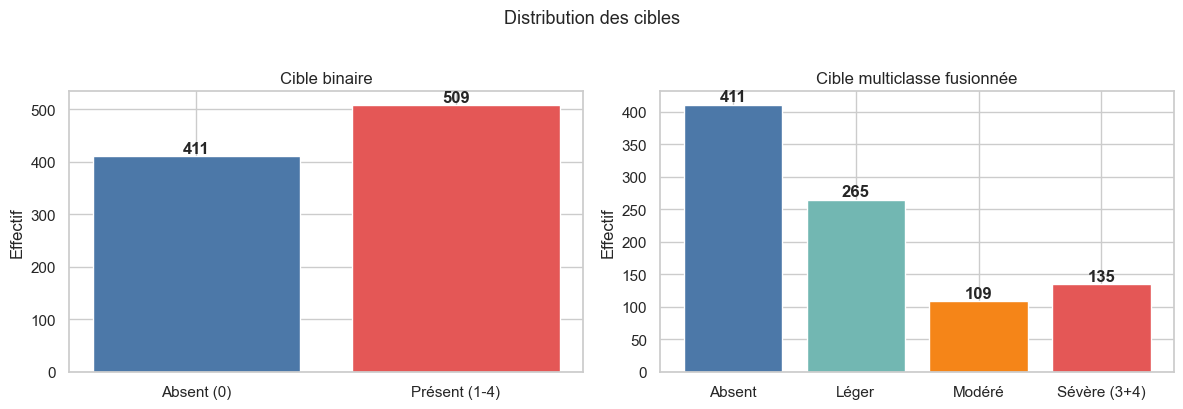

In [4]:
# ============================================================
# PRÉPARATION DE LA CIBLE
# ============================================================
# On part du DataFrame df déjà chargé dans le notebook EDA.
# Deux formulations de la cible sont construites :
#   - Binaire       : 0 (absent) vs 1 (présent, toutes sévérités)
#   - Multiclasse   : 0, 1, 2, 3+ (classes 3 et 4 fusionnées)
#
# Justification de la fusion 3+4 :
#   La classe 4 ne compte que 43 observations sur 920.
#   Cliniquement, les classes 3 et 4 correspondent toutes deux
#   à une maladie coronarienne sévère multi-vasculaire.
#   La frontière 3 vs 4 est moins nette que les autres frontières.
# ============================================================

# --- Cible binaire ---
y_binary = (df["num"] > 0).astype(int)

# --- Cible multiclasse fusionnée ---
y_multi = df["num"].replace({4: 3}).astype(int)

# --- Vérification des distributions ---
label_map_binary = {0: "Absent (0)", 1: "Présent (1-4)"}
label_map_multi  = {0: "Absent", 1: "Léger", 2: "Modéré", 3: "Sévère (3+4)"}

dist_binary = (
    y_binary.value_counts()
    .sort_index()
    .rename(index=label_map_binary)
    .to_frame("effectif")
)
dist_binary["proportion (%)"] = (
    dist_binary["effectif"] / len(y_binary) * 100
).round(1)

dist_multi = (
    y_multi.value_counts()
    .sort_index()
    .rename(index=label_map_multi)
    .to_frame("effectif")
)
dist_multi["proportion (%)"] = (
    dist_multi["effectif"] / len(y_multi) * 100
).round(1)

print("Distribution — cible binaire")
display(dist_binary)

print("\nDistribution — cible multiclasse fusionnée")
display(dist_multi)

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_bin   = ["#4C78A8", "#E45756"]
colors_multi = ["#4C78A8", "#72B7B2", "#F58518", "#E45756"]

axes[0].bar(dist_binary.index, dist_binary["effectif"],
            color=colors_bin)
axes[0].set_title("Cible binaire")
axes[0].set_ylabel("Effectif")
for i, v in enumerate(dist_binary["effectif"]):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

axes[1].bar(dist_multi.index, dist_multi["effectif"],
            color=colors_multi)
axes[1].set_title("Cible multiclasse fusionnée")
axes[1].set_ylabel("Effectif")
for i, v in enumerate(dist_multi["effectif"]):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("Distribution des cibles", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# SPLIT TRAIN / TEST ET DÉFINITION DU PRÉPROCESSEUR
# ============================================================
# Le jeu de test (20%) est mis de côté immédiatement.
# Il ne sera utilisé qu'une seule fois à la fin pour évaluer
# le modèle final — jamais pendant la phase de sélection.
#
# Le préprocesseur applique :
#   - Sur les variables quantitatives :
#       KNNImputer (n_neighbors=5) puis StandardScaler
#   - Sur les variables catégorielles :
#       SimpleImputer (mode) puis OneHotEncoder
#
# Toutes les transformations sont intégrées dans un pipeline
# sklearn — elles seront apprises uniquement sur le train
# à chaque fold de validation croisée. Pas de data leakage.
# ============================================================

# --- Définition des variables ---
features = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal"
]

num_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_features = ["sex", "cp", "fbs", "restecg", "exang",
                "slope", "ca", "thal"]

X = df[features].copy()

# --- Split binaire ---
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_binary,
)

# --- Split multiclasse ---
X_train_mul, X_test_mul, y_train_mul, y_test_mul = train_test_split(
    X, y_multi,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_multi,
)

print("Tailles des jeux de données")
print(f"  Train binaire     : {X_train_bin.shape}")
print(f"  Test  binaire     : {X_test_bin.shape}")
print(f"  Train multiclasse : {X_train_mul.shape}")
print(f"  Test  multiclasse : {X_test_mul.shape}")

# Vérification que la stratification a bien fonctionné
print("\nProportion de la cible dans train et test — binaire")
print(f"  Train : {y_train_bin.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Test  : {y_test_bin.value_counts(normalize=True).round(3).to_dict()}")

print("\nProportion de la cible dans train et test — multiclasse")
print(f"  Train : {y_train_mul.value_counts(normalize=True).sort_index().round(3).to_dict()}")
print(f"  Test  : {y_test_mul.value_counts(normalize=True).sort_index().round(3).to_dict()}")

# ============================================================
# DÉFINITION DU PRÉPROCESSEUR
# ============================================================

# Pipeline pour les variables quantitatives
num_pipeline = Pipeline(steps=[
    ("imputation_knn", KNNImputer(n_neighbors=5)),
    ("standardisation", StandardScaler()),
])

# Pipeline pour les variables catégorielles
cat_pipeline = Pipeline(steps=[
    ("imputation_mode", SimpleImputer(strategy="most_frequent")),
    ("encodage_ohe",    OneHotEncoder(handle_unknown="ignore",
                                      sparse_output=False)),
])

# Assemblage via ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("numerique",     num_pipeline, num_features),
        ("categorielle",  cat_pipeline, cat_features),
    ],
    remainder="drop",
)

print("\nPréprocesseur défini")
print("  Variables numériques  :", num_features)
print("  Variables catégorielles:", cat_features)

Tailles des jeux de données
  Train binaire     : (736, 13)
  Test  binaire     : (184, 13)
  Train multiclasse : (736, 13)
  Test  multiclasse : (184, 13)

Proportion de la cible dans train et test — binaire
  Train : {1: 0.553, 0: 0.447}
  Test  : {1: 0.554, 0: 0.446}

Proportion de la cible dans train et test — multiclasse
  Train : {0: 0.447, 1: 0.288, 2: 0.118, 3: 0.147}
  Test  : {0: 0.446, 1: 0.288, 2: 0.12, 3: 0.147}

Préprocesseur défini
  Variables numériques  : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
  Variables catégorielles: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']



  Dummy Classifier (baseline)
              precision    recall  f1-score   support

      Absent       0.00      0.00      0.00        82
     Présent       0.55      1.00      0.71       102

    accuracy                           0.55       184
   macro avg       0.28      0.50      0.36       184
weighted avg       0.31      0.55      0.40       184

  ROC-AUC  : 0.5000
  F-beta(2): 0.8615


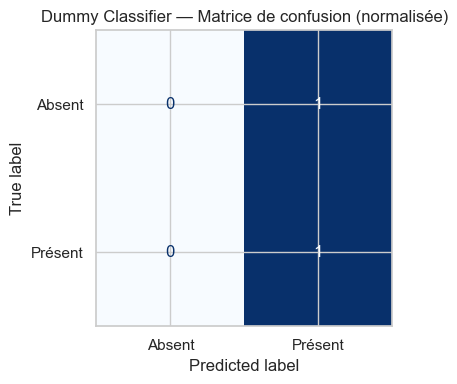


Interprétation :
  Le Dummy prédit toujours 'Présent' (classe majoritaire).
  Recall = 1.0 car il déclare tout le monde malade.
  Precision faible car il se trompe sur tous les sains.
  C'est le plancher — tout modèle doit faire mieux.


In [6]:
# ============================================================
# FONCTION D'ÉVALUATION — utilisée pour tous les modèles
# ============================================================
# Cette fonction prend un pipeline déjà entraîné et retourne
# un tableau de métriques sur le jeu de test.
# Métriques retenues :
#   - Recall    : priorité 1 — combien de malades détectés
#   - Precision : priorité 2 — garde-fou contre les faux positifs
#   - F-beta(β=2) : favorise le recall sur la precision
#   - F1        : équilibre recall/precision
#   - ROC-AUC   : discrimination globale
# ============================================================

def evaluer_modele_binaire(pipeline, X_test, y_test, nom_modele):
    """
    Évalue un pipeline binaire sur le jeu de test.
    Affiche le rapport de classification et retourne
    un dictionnaire de métriques.
    """
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    resultats = {
        "modèle":     nom_modele,
        "recall":     recall_score(y_test, y_pred, zero_division=0),
        "precision":  precision_score(y_test, y_pred, zero_division=0),
        "f_beta_2":   fbeta_score(y_test, y_pred, beta=2,
                                   zero_division=0),
        "f1":         f1_score(y_test, y_pred, zero_division=0),
        "roc_auc":    roc_auc_score(y_test, y_proba),
        "accuracy":   accuracy_score(y_test, y_pred),
    }

    print(f"\n{'='*50}")
    print(f"  {nom_modele}")
    print(f"{'='*50}")
    print(classification_report(
        y_test, y_pred,
        target_names=["Absent", "Présent"],
        zero_division=0
    ))
    print(f"  ROC-AUC  : {resultats['roc_auc']:.4f}")
    print(f"  F-beta(2): {resultats['f_beta_2']:.4f}")

    return resultats


# ============================================================
# MODÈLE 1 — DUMMY CLASSIFIER (baseline de référence)
# ============================================================
# Le Dummy Classifier prédit toujours la classe majoritaire
# sans regarder les variables explicatives.
# C'est notre plancher absolu — tout modèle doit faire mieux.
# ============================================================

# Construction du pipeline
dummy_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", DummyClassifier(
        strategy="most_frequent",
        random_state=RANDOM_STATE
    )),
])

# Entraînement sur le train
dummy_pipeline.fit(X_train_bin, y_train_bin)

# Évaluation sur le test
resultats_dummy = evaluer_modele_binaire(
    dummy_pipeline, X_test_bin, y_test_bin,
    nom_modele="Dummy Classifier (baseline)"
)

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    dummy_pipeline, X_test_bin, y_test_bin,
    display_labels=["Absent", "Présent"],
    normalize="true",
    colorbar=False,
    cmap="Blues",
    ax=ax,
)
ax.set_title("Dummy Classifier — Matrice de confusion (normalisée)")
plt.tight_layout()
plt.show()

print("\nInterprétation :")
print("  Le Dummy prédit toujours 'Présent' (classe majoritaire).")
print("  Recall = 1.0 car il déclare tout le monde malade.")
print("  Precision faible car il se trompe sur tous les sains.")
print("  C'est le plancher — tout modèle doit faire mieux.")

Le Dummy prédit "Présent" pour tout le monde — c'est visible dans la matrice de confusion où toute la colonne gauche est à 0 et toute la colonne droite est à 1.
Recall = 1.0 sur "Présent" — normal, il dit toujours malade donc il ne rate aucun malade
Recall = 0.0 sur "Absent" — il ne détecte aucun sain
Precision = 0.55 — sur les 184 patients classés malades, seulement 55% le sont vraiment
ROC-AUC = 0.50 — exactement le hasard, c'est le plancher absolu
Accuracy = 0.55 — il a raison 55% du temps uniquement parce que 55% du dataset est malade

BASELINE — avant optimisation

  Régression Logistique — Baseline
              precision    recall  f1-score   support

      Absent       0.83      0.79      0.81        82
     Présent       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184

  ROC-AUC  : 0.9115
  F-beta(2): 0.8658


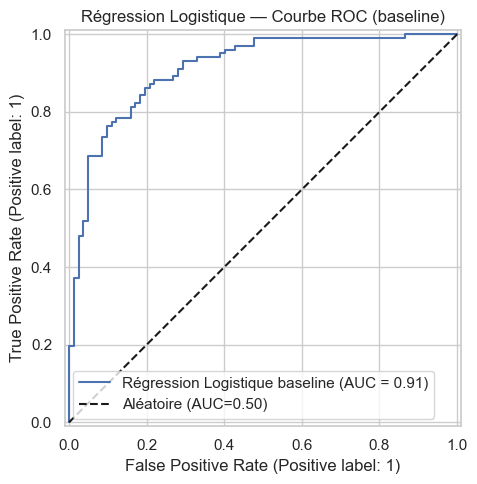


Meilleurs hyperparamètres :
  {'modele__C': 0.01, 'modele__penalty': 'l2', 'modele__solver': 'lbfgs'}
  Meilleur recall CV : 0.8525

APRÈS OPTIMISATION

  Régression Logistique — Optimisée
              precision    recall  f1-score   support

      Absent       0.82      0.73      0.77        82
     Présent       0.80      0.87      0.84       102

    accuracy                           0.81       184
   macro avg       0.81      0.80      0.80       184
weighted avg       0.81      0.81      0.81       184

  ROC-AUC  : 0.8984
  F-beta(2): 0.8574


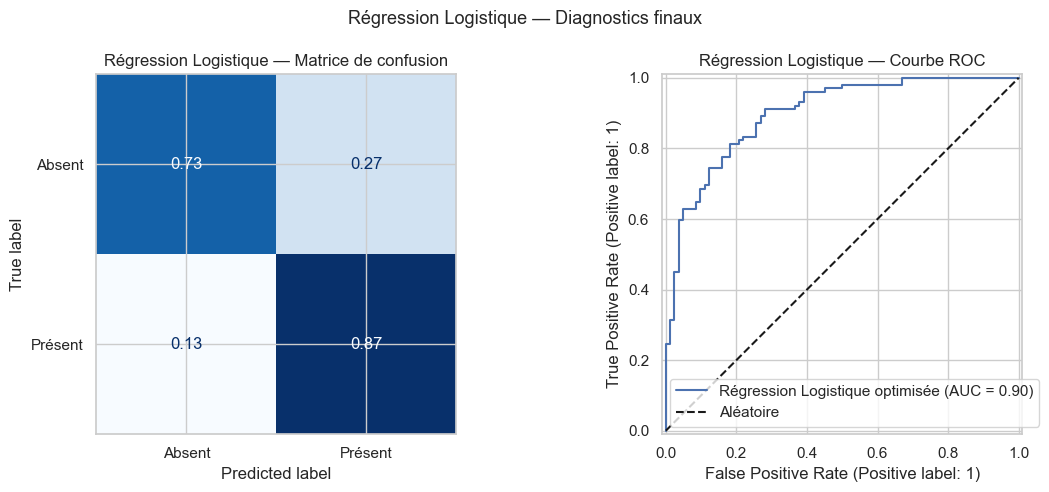

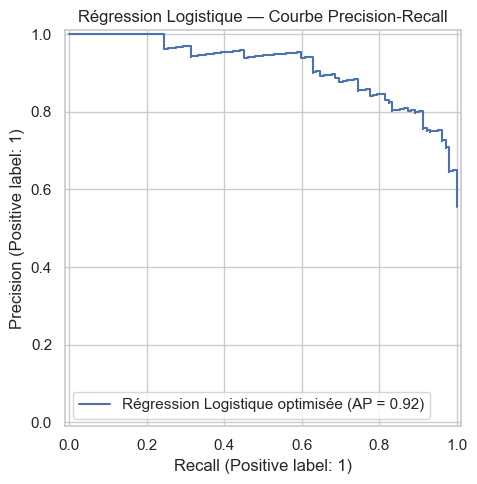

In [7]:
# ============================================================
# MODÈLE 2 — RÉGRESSION LOGISTIQUE
# ============================================================
# Modèle linéaire de référence — interprétable et rapide.
# On commence par une baseline sans optimisation,
# puis on optimise les hyperparamètres via GridSearchCV.
# ============================================================

# --- Baseline ---
rl_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

# Entraînement
rl_pipeline.fit(X_train_bin, y_train_bin)

# Évaluation baseline
print("BASELINE — avant optimisation")
resultats_rl_baseline = evaluer_modele_binaire(
    rl_pipeline, X_test_bin, y_test_bin,
    nom_modele="Régression Logistique — Baseline"
)

# Courbe ROC baseline
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(
    rl_pipeline, X_test_bin, y_test_bin, ax=ax,
    name="Régression Logistique baseline"
)
ax.plot([0, 1], [0, 1], "k--", label="Aléatoire (AUC=0.50)")
ax.set_title("Régression Logistique — Courbe ROC (baseline)")
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# OPTIMISATION DES HYPERPARAMÈTRES — GridSearchCV
# ============================================================
# On cherche les meilleurs hyperparamètres sur le train
# via une validation croisée stratifiée à 5 folds.
# Le critère d'optimisation est le recall — priorité médicale.
# ============================================================

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True,
                     random_state=RANDOM_STATE)

rl_param_grid = {
    "modele__C":       [0.01, 0.1, 1, 5, 10],
    "modele__penalty": ["l2"],
    "modele__solver":  ["lbfgs", "liblinear"],
}

rl_grid_search = GridSearchCV(
    rl_pipeline,
    rl_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True,
)

rl_grid_search.fit(X_train_bin, y_train_bin)

print("\nMeilleurs hyperparamètres :")
print(f"  {rl_grid_search.best_params_}")
print(f"  Meilleur recall CV : {rl_grid_search.best_score_:.4f}")

# --- Évaluation du modèle optimisé ---
print("\nAPRÈS OPTIMISATION")
resultats_rl = evaluer_modele_binaire(
    rl_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    nom_modele="Régression Logistique — Optimisée"
)

# Matrice de confusion + Courbe ROC côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    rl_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    display_labels=["Absent", "Présent"],
    normalize="true",
    colorbar=False,
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Régression Logistique — Matrice de confusion")

RocCurveDisplay.from_estimator(
    rl_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    ax=axes[1],
    name="Régression Logistique optimisée"
)
axes[1].plot([0, 1], [0, 1], "k--", label="Aléatoire")
axes[1].set_title("Régression Logistique — Courbe ROC")
axes[1].legend()

plt.suptitle("Régression Logistique — Diagnostics finaux", fontsize=13)
plt.tight_layout()
plt.show()

# Courbe Precision-Recall
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_estimator(
    rl_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    ax=ax,
    name="Régression Logistique optimisée"
)
ax.set_title("Régression Logistique — Courbe Precision-Recall")
plt.tight_layout()
plt.show()

# Sauvegarde des résultats pour la comparaison finale
rl_grid_search_bin = rl_grid_search

BASELINE — avant optimisation

  KNN — Baseline
              precision    recall  f1-score   support

      Absent       0.83      0.77      0.80        82
     Présent       0.82      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184

  ROC-AUC  : 0.8870
  F-beta(2): 0.8624

Meilleurs hyperparamètres :
  {'modele__metric': 'euclidean', 'modele__n_neighbors': 5, 'modele__weights': 'uniform'}
  Meilleur recall CV : 0.8575

APRÈS OPTIMISATION

  KNN — Optimisé
              precision    recall  f1-score   support

      Absent       0.83      0.77      0.80        82
     Présent       0.82      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184

  ROC-AUC  : 0.8870
  F-beta(2): 0.8624


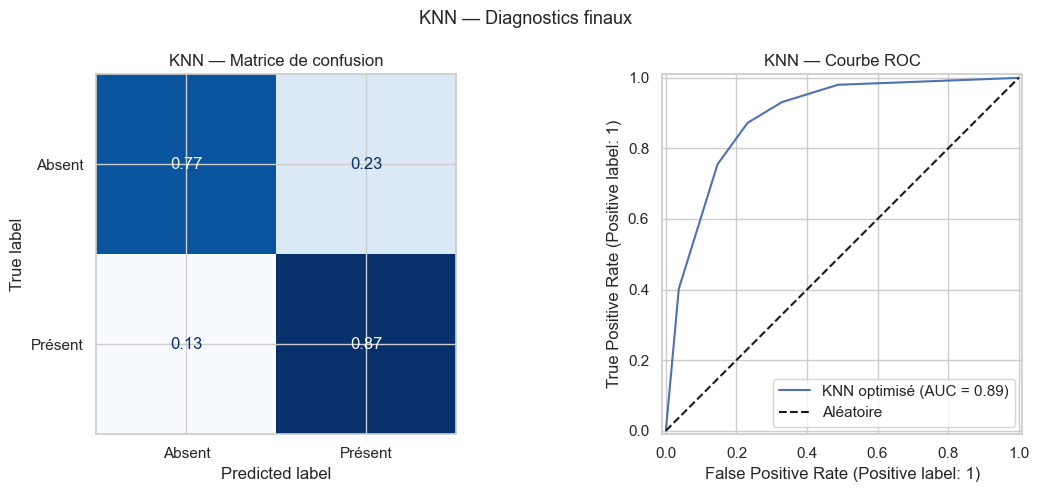

In [10]:
# ============================================================
# MODÈLE 3 — K-NEAREST NEIGHBORS (KNN)
# ============================================================


# --- Baseline ---
knn_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", KNeighborsClassifier(n_neighbors=5)),
])

knn_pipeline.fit(X_train_bin, y_train_bin)

print("BASELINE — avant optimisation")
resultats_knn_baseline = evaluer_modele_binaire(
    knn_pipeline, X_test_bin, y_test_bin,
    nom_modele="KNN — Baseline"
)

# ============================================================
# OPTIMISATION
# ============================================================

knn_param_grid = {
    "modele__n_neighbors": [3, 5, 7, 9, 11, 15],
    "modele__weights":     ["uniform", "distance"],
    "modele__metric":      ["euclidean", "manhattan"],
}

knn_grid_search = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True,
)

knn_grid_search.fit(X_train_bin, y_train_bin)

print("\nMeilleurs hyperparamètres :")
print(f"  {knn_grid_search.best_params_}")
print(f"  Meilleur recall CV : {knn_grid_search.best_score_:.4f}")

print("\nAPRÈS OPTIMISATION")
resultats_knn = evaluer_modele_binaire(
    knn_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    nom_modele="KNN — Optimisé"
)

# Diagnostics visuels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    knn_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    display_labels=["Absent", "Présent"],
    normalize="true",
    colorbar=False,
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("KNN — Matrice de confusion")

RocCurveDisplay.from_estimator(
    knn_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    ax=axes[1],
    name="KNN optimisé"
)
axes[1].plot([0, 1], [0, 1], "k--", label="Aléatoire")
axes[1].set_title("KNN — Courbe ROC")
axes[1].legend()

plt.suptitle("KNN — Diagnostics finaux", fontsize=13)
plt.tight_layout()
plt.show()

# Sauvegarde
knn_grid_search_bin = knn_grid_search

BASELINE — avant optimisation

  Decision Tree — Baseline
              precision    recall  f1-score   support

      Absent       0.78      0.77      0.77        82
     Présent       0.82      0.82      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184

  ROC-AUC  : 0.7959
  F-beta(2): 0.8219

Meilleurs hyperparamètres :
  {'modele__criterion': 'entropy', 'modele__max_depth': 3, 'modele__min_samples_leaf': 1, 'modele__min_samples_split': 2}
  Meilleur recall CV : 0.7983

APRÈS OPTIMISATION

  Decision Tree — Optimisé
              precision    recall  f1-score   support

      Absent       0.83      0.73      0.78        82
     Présent       0.80      0.88      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.81       184
weighted avg       0.82      0.82      0.81       184

  ROC-AUC  : 0.8923

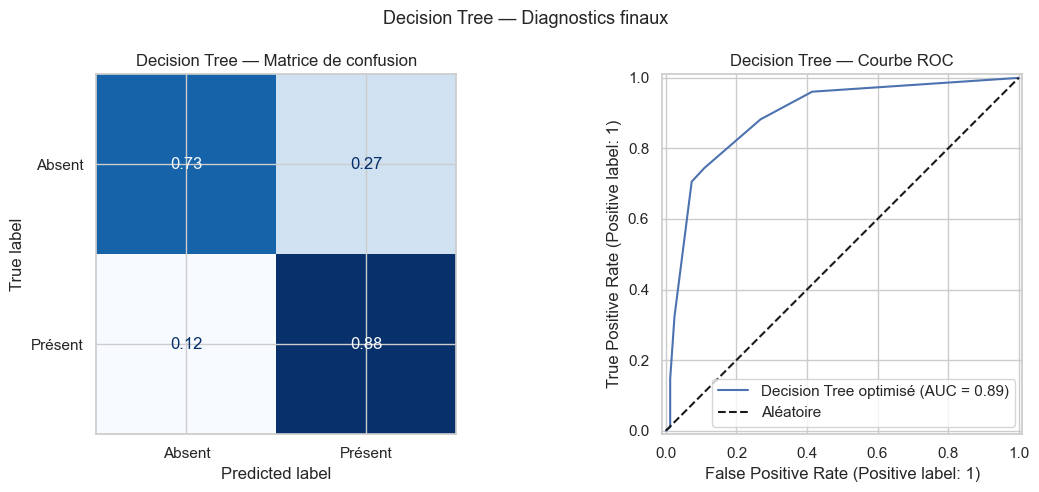

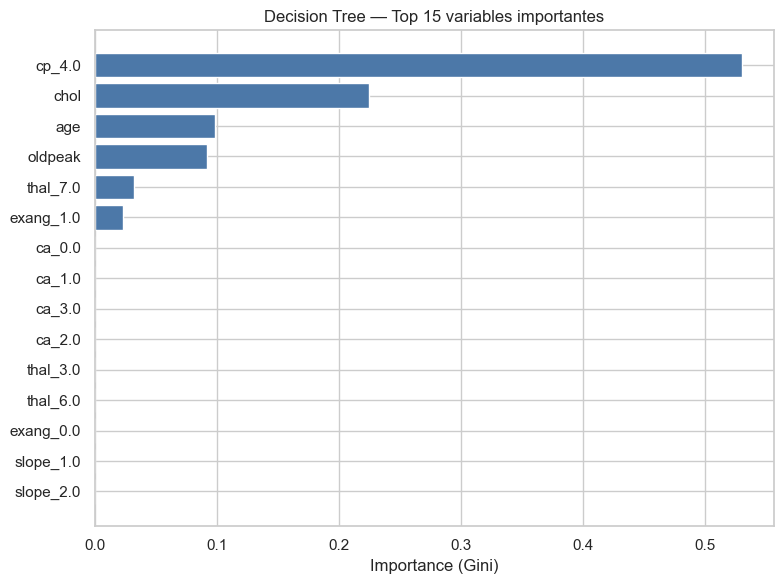

In [11]:
# ============================================================
# MODÈLE 4 — ARBRE DE DÉCISION
# ============================================================


# --- Baseline ---
dt_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

dt_pipeline.fit(X_train_bin, y_train_bin)

print("BASELINE — avant optimisation")
resultats_dt_baseline = evaluer_modele_binaire(
    dt_pipeline, X_test_bin, y_test_bin,
    nom_modele="Decision Tree — Baseline"
)

# ============================================================
# OPTIMISATION
# ============================================================

dt_param_grid = {
    "modele__max_depth":        [3, 5, 7, 10, None],
    "modele__min_samples_split": [2, 5, 10, 20],
    "modele__min_samples_leaf":  [1, 2, 5],
    "modele__criterion":         ["gini", "entropy"],
}

dt_grid_search = GridSearchCV(
    dt_pipeline,
    dt_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True,
)

dt_grid_search.fit(X_train_bin, y_train_bin)

print("\nMeilleurs hyperparamètres :")
print(f"  {dt_grid_search.best_params_}")
print(f"  Meilleur recall CV : {dt_grid_search.best_score_:.4f}")

print("\nAPRÈS OPTIMISATION")
resultats_dt = evaluer_modele_binaire(
    dt_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    nom_modele="Decision Tree — Optimisé"
)

# Diagnostics visuels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    dt_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    display_labels=["Absent", "Présent"],
    normalize="true",
    colorbar=False,
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Decision Tree — Matrice de confusion")

RocCurveDisplay.from_estimator(
    dt_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    ax=axes[1],
    name="Decision Tree optimisé"
)
axes[1].plot([0, 1], [0, 1], "k--", label="Aléatoire")
axes[1].set_title("Decision Tree — Courbe ROC")
axes[1].legend()

plt.suptitle("Decision Tree — Diagnostics finaux", fontsize=13)
plt.tight_layout()
plt.show()

# Importance des variables
importances = (
    dt_grid_search.best_estimator_
    .named_steps["modele"]
    .feature_importances_
)

# Récupérer les noms des features après OHE
ohe_features = (
    dt_grid_search.best_estimator_
    .named_steps["preprocesseur"]
    .named_transformers_["categorielle"]
    .named_steps["encodage_ohe"]
    .get_feature_names_out(cat_features)
)
all_feature_names = num_features + list(ohe_features)

fi_df = (
    pd.DataFrame({
        "feature":    all_feature_names,
        "importance": importances,
    })
    .sort_values("importance", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df["feature"], fi_df["importance"], color="#4C78A8")
ax.set_xlabel("Importance (Gini)")
ax.set_title("Decision Tree — Top 15 variables importantes")
plt.tight_layout()
plt.show()

# Sauvegarde
dt_grid_search_bin = dt_grid_search

BASELINE — avant optimisation

  Random Forest — Baseline
              precision    recall  f1-score   support

      Absent       0.88      0.82      0.85        82
     Présent       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

  ROC-AUC  : 0.9255
  F-beta(2): 0.9012

Meilleurs hyperparamètres :
  {'modele__class_weight': None, 'modele__max_depth': None, 'modele__max_features': 'log2', 'modele__min_samples_split': 10, 'modele__n_estimators': 300}
  Meilleur recall CV : 0.8697

APRÈS OPTIMISATION

  Random Forest — Optimisé
              precision    recall  f1-score   support

      Absent       0.90      0.79      0.84        82
     Présent       0.85      0.93      0.89       102

    accuracy                           0.87       184
   macro avg       0.88      0.86      0.87       184
weighted avg       0.87      0.87      0.8

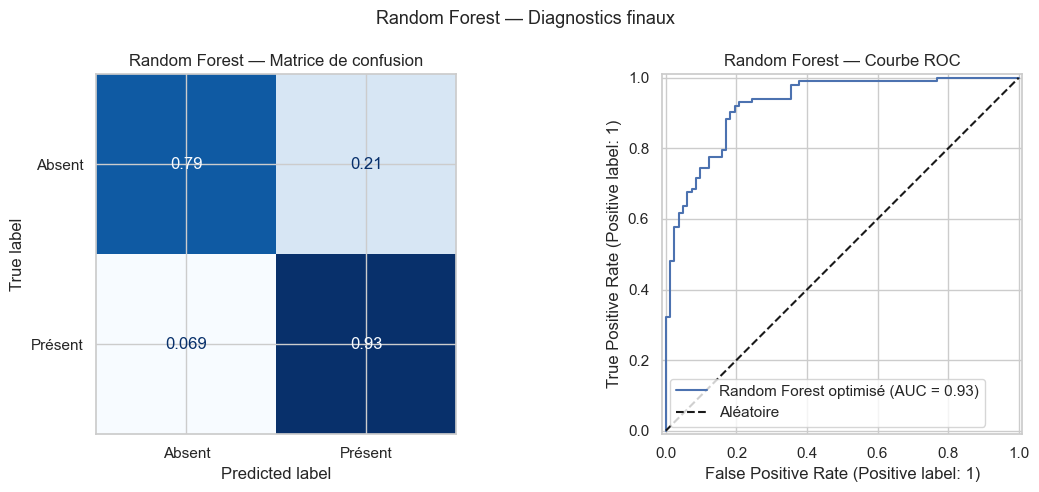

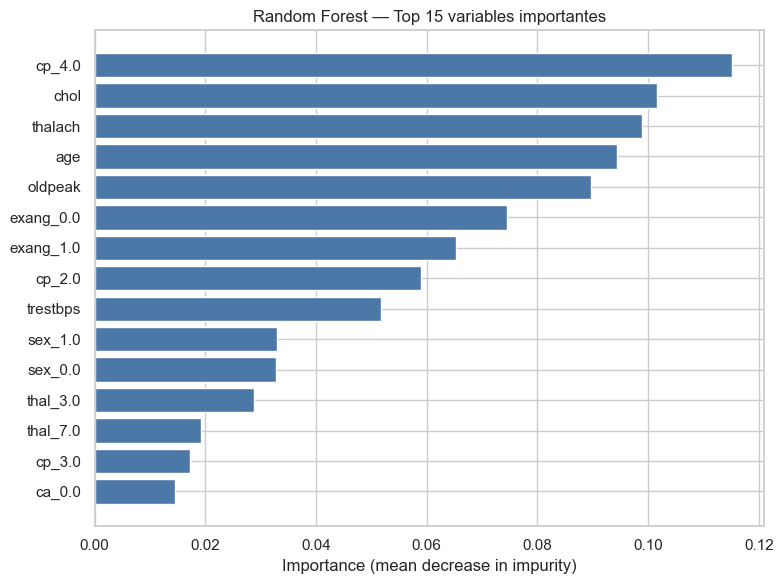

In [12]:
# ============================================================
# MODÈLE 5 — RANDOM FOREST
# ============================================================

# --- Baseline ---
rf_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
    )),
])

rf_pipeline.fit(X_train_bin, y_train_bin)

print("BASELINE — avant optimisation")
resultats_rf_baseline = evaluer_modele_binaire(
    rf_pipeline, X_test_bin, y_test_bin,
    nom_modele="Random Forest — Baseline"
)

# ============================================================
# OPTIMISATION
# ============================================================

rf_param_grid = {
    "modele__n_estimators":      [100, 200, 300],
    "modele__max_depth":         [None, 5, 10, 15],
    "modele__min_samples_split": [2, 5, 10],
    "modele__max_features":      ["sqrt", "log2"],
    "modele__class_weight":      [None, "balanced"],
}

rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True,
)

rf_grid_search.fit(X_train_bin, y_train_bin)

print("\nMeilleurs hyperparamètres :")
print(f"  {rf_grid_search.best_params_}")
print(f"  Meilleur recall CV : {rf_grid_search.best_score_:.4f}")

print("\nAPRÈS OPTIMISATION")
resultats_rf = evaluer_modele_binaire(
    rf_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    nom_modele="Random Forest — Optimisé"
)

# Diagnostics visuels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    rf_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    display_labels=["Absent", "Présent"],
    normalize="true",
    colorbar=False,
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Random Forest — Matrice de confusion")

RocCurveDisplay.from_estimator(
    rf_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    ax=axes[1],
    name="Random Forest optimisé"
)
axes[1].plot([0, 1], [0, 1], "k--", label="Aléatoire")
axes[1].set_title("Random Forest — Courbe ROC")
axes[1].legend()

plt.suptitle("Random Forest — Diagnostics finaux", fontsize=13)
plt.tight_layout()
plt.show()

# Importance des variables
importances_rf = (
    rf_grid_search.best_estimator_
    .named_steps["modele"]
    .feature_importances_
)

ohe_features_rf = (
    rf_grid_search.best_estimator_
    .named_steps["preprocesseur"]
    .named_transformers_["categorielle"]
    .named_steps["encodage_ohe"]
    .get_feature_names_out(cat_features)
)
all_feature_names_rf = num_features + list(ohe_features_rf)

fi_df_rf = (
    pd.DataFrame({
        "feature":    all_feature_names_rf,
        "importance": importances_rf,
    })
    .sort_values("importance", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df_rf["feature"], fi_df_rf["importance"],
        color="#4C78A8")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title("Random Forest — Top 15 variables importantes")
plt.tight_layout()
plt.show()

# Sauvegarde
rf_grid_search_bin = rf_grid_search

BASELINE — avant optimisation

  Extra Trees — Baseline
              precision    recall  f1-score   support

      Absent       0.82      0.79      0.81        82
     Présent       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184

  ROC-AUC  : 0.9219
  F-beta(2): 0.8577

Meilleurs hyperparamètres :
  {'modele__class_weight': None, 'modele__max_depth': 10, 'modele__max_features': 'sqrt', 'modele__min_samples_split': 10, 'modele__n_estimators': 200}
  Meilleur recall CV : 0.8573

APRÈS OPTIMISATION

  Extra Trees — Optimisé
              precision    recall  f1-score   support

      Absent       0.89      0.77      0.82        82
     Présent       0.83      0.92      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.84      0.85       184
weighted avg       0.86      0.85      0.85     

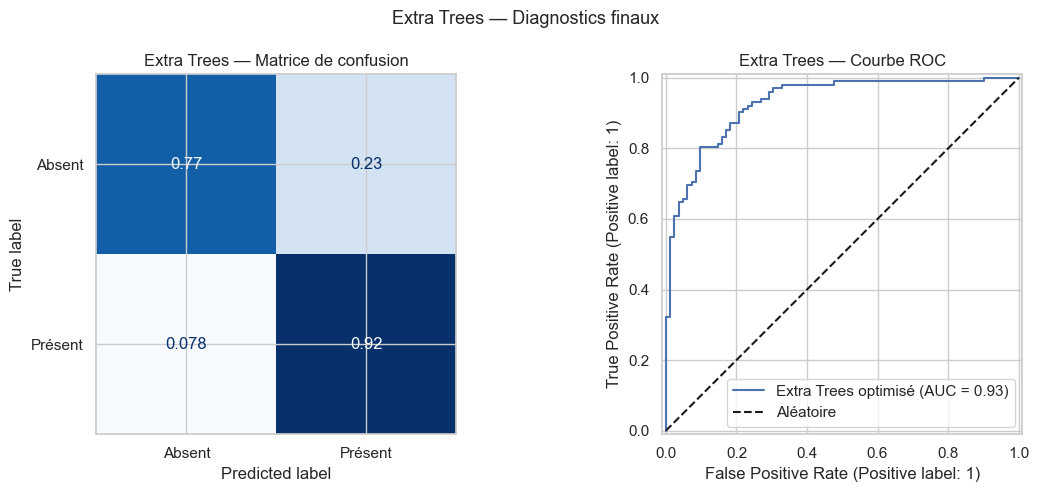

In [13]:
# ============================================================
# MODÈLE 6 — EXTRA TREES
# ============================================================


# --- Baseline ---
et_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", ExtraTreesClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
    )),
])

et_pipeline.fit(X_train_bin, y_train_bin)

print("BASELINE — avant optimisation")
resultats_et_baseline = evaluer_modele_binaire(
    et_pipeline, X_test_bin, y_test_bin,
    nom_modele="Extra Trees — Baseline"
)

# ============================================================
# OPTIMISATION
# ============================================================

et_param_grid = {
    "modele__n_estimators":      [100, 200, 300],
    "modele__max_depth":         [None, 5, 10, 15],
    "modele__min_samples_split": [2, 5, 10],
    "modele__max_features":      ["sqrt", "log2"],
    "modele__class_weight":      [None, "balanced"],
}

et_grid_search = GridSearchCV(
    et_pipeline,
    et_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True,
)

et_grid_search.fit(X_train_bin, y_train_bin)

print("\nMeilleurs hyperparamètres :")
print(f"  {et_grid_search.best_params_}")
print(f"  Meilleur recall CV : {et_grid_search.best_score_:.4f}")

print("\nAPRÈS OPTIMISATION")
resultats_et = evaluer_modele_binaire(
    et_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    nom_modele="Extra Trees — Optimisé"
)

# Diagnostics visuels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    et_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    display_labels=["Absent", "Présent"],
    normalize="true",
    colorbar=False,
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Extra Trees — Matrice de confusion")

RocCurveDisplay.from_estimator(
    et_grid_search.best_estimator_,
    X_test_bin, y_test_bin,
    ax=axes[1],
    name="Extra Trees optimisé"
)
axes[1].plot([0, 1], [0, 1], "k--", label="Aléatoire")
axes[1].set_title("Extra Trees — Courbe ROC")
axes[1].legend()

plt.suptitle("Extra Trees — Diagnostics finaux", fontsize=13)
plt.tight_layout()
plt.show()

# Sauvegarde
et_grid_search_bin = et_grid_search

BASELINE — avant optimisation

  Gradient Boosting — Baseline
              precision    recall  f1-score   support

      Absent       0.89      0.78      0.83        82
     Présent       0.84      0.92      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184

  ROC-AUC  : 0.9124
  F-beta(2): 0.9038

Meilleurs hyperparamètres :
  {'modele__learning_rate': 0.01, 'modele__max_depth': 3, 'modele__min_samples_split': 2, 'modele__n_estimators': 50, 'modele__subsample': 1.0}
  Meilleur recall CV : 0.8795

APRÈS OPTIMISATION

  Gradient Boosting — Optimisé
              precision    recall  f1-score   support

      Absent       0.88      0.70      0.78        82
     Présent       0.79      0.92      0.85       102

    accuracy                           0.82       184
   macro avg       0.83      0.81      0.81       184
weighted avg       0.83      0.82      0.82 

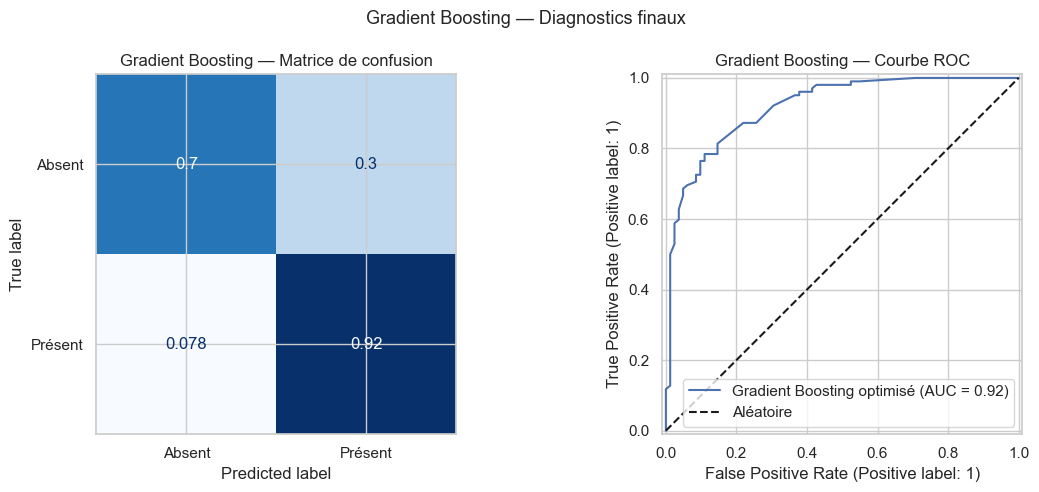

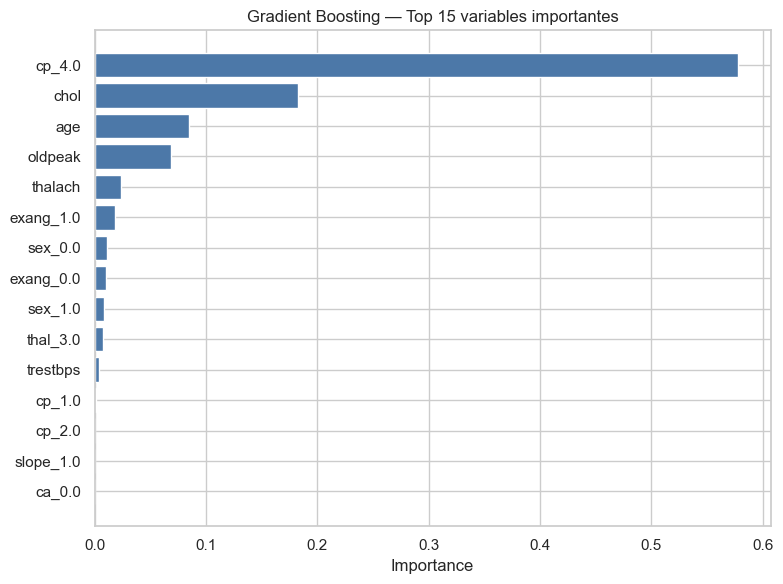

In [14]:
# ============================================================
# MODÈLE 7 — GRADIENT BOOSTING MACHINE (GBM)
# ============================================================

# --- Baseline ---
gbm_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    )),
])

gbm_pipeline.fit(X_train_bin, y_train_bin)

print("BASELINE — avant optimisation")

resultats_gbm_baseline = evaluer_modele_binaire(
    gbm_pipeline,
    X_test_bin,
    y_test_bin,
    nom_modele="Gradient Boosting — Baseline"
)

# ============================================================
# OPTIMISATION
# ============================================================

gbm_param_grid = {
    "modele__n_estimators":  [50, 100, 200],
    "modele__learning_rate": [0.01, 0.05, 0.1],
    "modele__max_depth":     [2, 3, 5],
    "modele__subsample":     [0.8, 1.0],
    "modele__min_samples_split": [2, 5, 10],
}

gbm_grid_search = GridSearchCV(
    gbm_pipeline,
    gbm_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True,
)

gbm_grid_search.fit(X_train_bin, y_train_bin)

print("\nMeilleurs hyperparamètres :")
print(f"  {gbm_grid_search.best_params_}")
print(f"  Meilleur recall CV : {gbm_grid_search.best_score_:.4f}")

print("\nAPRÈS OPTIMISATION")

resultats_gbm = evaluer_modele_binaire(
    gbm_grid_search.best_estimator_,
    X_test_bin,
    y_test_bin,
    nom_modele="Gradient Boosting — Optimisé"
)

# ============================================================
# DIAGNOSTICS VISUELS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    gbm_grid_search.best_estimator_,
    X_test_bin,
    y_test_bin,
    display_labels=["Absent", "Présent"],
    normalize="true",
    colorbar=False,
    cmap="Blues",
    ax=axes[0],
)

axes[0].set_title(
    "Gradient Boosting — Matrice de confusion"
)

RocCurveDisplay.from_estimator(
    gbm_grid_search.best_estimator_,
    X_test_bin,
    y_test_bin,
    ax=axes[1],
    name="Gradient Boosting optimisé"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Aléatoire"
)

axes[1].set_title(
    "Gradient Boosting — Courbe ROC"
)

axes[1].legend()

plt.suptitle(
    "Gradient Boosting — Diagnostics finaux",
    fontsize=13
)

plt.tight_layout()
plt.show()

# ============================================================
# IMPORTANCE DES VARIABLES
# ============================================================

importances_gbm = (
    gbm_grid_search.best_estimator_
    .named_steps["modele"]
    .feature_importances_
)

# Récupération des variables après OHE
ohe_features_gbm = (
    gbm_grid_search.best_estimator_
    .named_steps["preprocesseur"]
    .named_transformers_["categorielle"]
    .named_steps["encodage_ohe"]
    .get_feature_names_out(cat_features)
)

all_feature_names_gbm = (
    num_features + list(ohe_features_gbm)
)

fi_df_gbm = (
    pd.DataFrame({
        "feature": all_feature_names_gbm,
        "importance": importances_gbm,
    })
    .sort_values("importance", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    fi_df_gbm["feature"],
    fi_df_gbm["importance"],
    color="#4C78A8"
)

ax.set_xlabel("Importance")

ax.set_title(
    "Gradient Boosting — Top 15 variables importantes"
)

plt.tight_layout()
plt.show()

# ============================================================
# SAUVEGARDE
# ============================================================

gbm_grid_search_bin = gbm_grid_search

BASELINE — avant optimisation

  XGBoost — Baseline
              precision    recall  f1-score   support

      Absent       0.90      0.76      0.82        82
     Présent       0.83      0.93      0.88       102

    accuracy                           0.85       184
   macro avg       0.86      0.84      0.85       184
weighted avg       0.86      0.85      0.85       184

  ROC-AUC  : 0.8919
  F-beta(2): 0.9082

Meilleurs hyperparamètres :
  {'modele__colsample_bytree': 1.0, 'modele__learning_rate': 0.01, 'modele__max_depth': 3, 'modele__n_estimators': 50, 'modele__subsample': 1.0}
  Meilleur recall CV : 0.8919

APRÈS OPTIMISATION

  XGBoost — Optimisé
              precision    recall  f1-score   support

      Absent       0.93      0.61      0.74        82
     Présent       0.75      0.96      0.84       102

    accuracy                           0.80       184
   macro avg       0.84      0.79      0.79       184
weighted avg       0.83      0.80      0.80       184

  ROC-AU

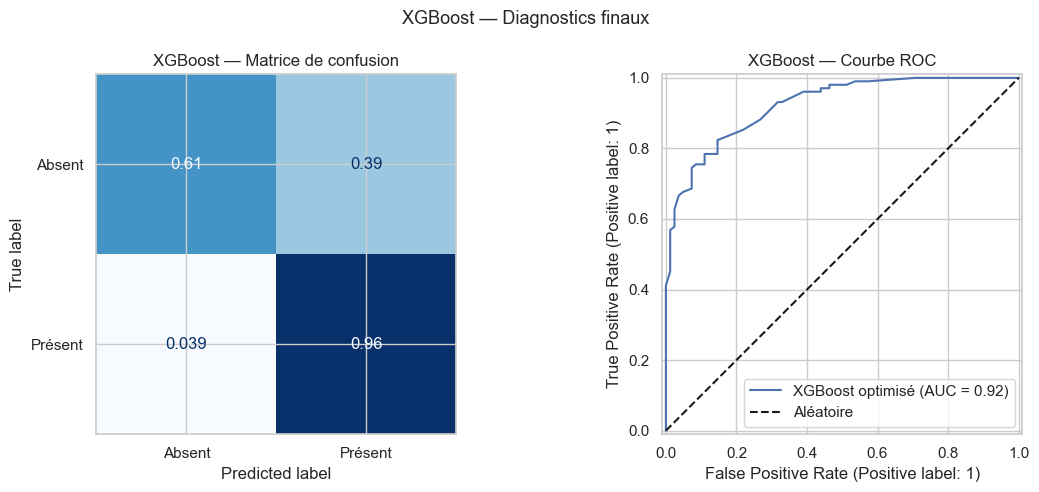

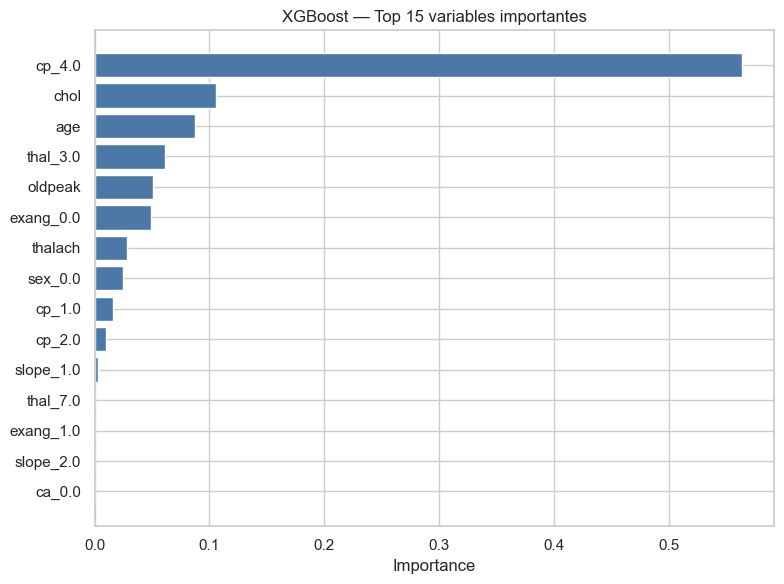

In [15]:
# ============================================================
# MODÈLE 8 — XGBOOST
# ============================================================


from xgboost import XGBClassifier

# --- Baseline ---
xgb_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False,
    )),
])

xgb_pipeline.fit(X_train_bin, y_train_bin)

print("BASELINE — avant optimisation")

resultats_xgb_baseline = evaluer_modele_binaire(
    xgb_pipeline,
    X_test_bin,
    y_test_bin,
    nom_modele="XGBoost — Baseline"
)

# ============================================================
# OPTIMISATION
# ============================================================

xgb_param_grid = {
    "modele__n_estimators":  [50, 100, 200],
    "modele__learning_rate": [0.01, 0.05, 0.1],
    "modele__max_depth":     [2, 3, 5],
    "modele__subsample":     [0.8, 1.0],
    "modele__colsample_bytree": [0.8, 1.0],
}

xgb_grid_search = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True,
)

xgb_grid_search.fit(X_train_bin, y_train_bin)

print("\nMeilleurs hyperparamètres :")
print(f"  {xgb_grid_search.best_params_}")
print(f"  Meilleur recall CV : {xgb_grid_search.best_score_:.4f}")

print("\nAPRÈS OPTIMISATION")

resultats_xgb = evaluer_modele_binaire(
    xgb_grid_search.best_estimator_,
    X_test_bin,
    y_test_bin,
    nom_modele="XGBoost — Optimisé"
)

# ============================================================
# DIAGNOSTICS VISUELS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    xgb_grid_search.best_estimator_,
    X_test_bin,
    y_test_bin,
    display_labels=["Absent", "Présent"],
    normalize="true",
    colorbar=False,
    cmap="Blues",
    ax=axes[0],
)

axes[0].set_title(
    "XGBoost — Matrice de confusion"
)

RocCurveDisplay.from_estimator(
    xgb_grid_search.best_estimator_,
    X_test_bin,
    y_test_bin,
    ax=axes[1],
    name="XGBoost optimisé"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Aléatoire"
)

axes[1].set_title(
    "XGBoost — Courbe ROC"
)

axes[1].legend()

plt.suptitle(
    "XGBoost — Diagnostics finaux",
    fontsize=13
)

plt.tight_layout()
plt.show()

# ============================================================
# IMPORTANCE DES VARIABLES
# ============================================================

importances_xgb = (
    xgb_grid_search.best_estimator_
    .named_steps["modele"]
    .feature_importances_
)

ohe_features_xgb = (
    xgb_grid_search.best_estimator_
    .named_steps["preprocesseur"]
    .named_transformers_["categorielle"]
    .named_steps["encodage_ohe"]
    .get_feature_names_out(cat_features)
)

all_feature_names_xgb = (
    num_features + list(ohe_features_xgb)
)

fi_df_xgb = (
    pd.DataFrame({
        "feature": all_feature_names_xgb,
        "importance": importances_xgb,
    })
    .sort_values("importance", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    fi_df_xgb["feature"],
    fi_df_xgb["importance"],
    color="#4C78A8"
)

ax.set_xlabel("Importance")

ax.set_title(
    "XGBoost — Top 15 variables importantes"
)

plt.tight_layout()
plt.show()

# ============================================================
# SAUVEGARDE
# ============================================================

xgb_grid_search_bin = xgb_grid_search

BASELINE — avant optimisation

  LightGBM — Baseline
              precision    recall  f1-score   support

      Absent       0.85      0.77      0.81        82
     Présent       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184

  ROC-AUC  : 0.9063
  F-beta(2): 0.8784

Meilleurs hyperparamètres :
  {'modele__colsample_bytree': 1.0, 'modele__learning_rate': 0.01, 'modele__max_depth': 3, 'modele__n_estimators': 50, 'modele__num_leaves': 15, 'modele__subsample': 0.8}
  Meilleur recall CV : 0.8968

APRÈS OPTIMISATION

  LightGBM — Optimisé
              precision    recall  f1-score   support

      Absent       0.93      0.62      0.74        82
     Présent       0.76      0.96      0.85       102

    accuracy                           0.81       184
   macro avg       0.84      0.79      0.80       184
weighted avg       0.83      0.81  

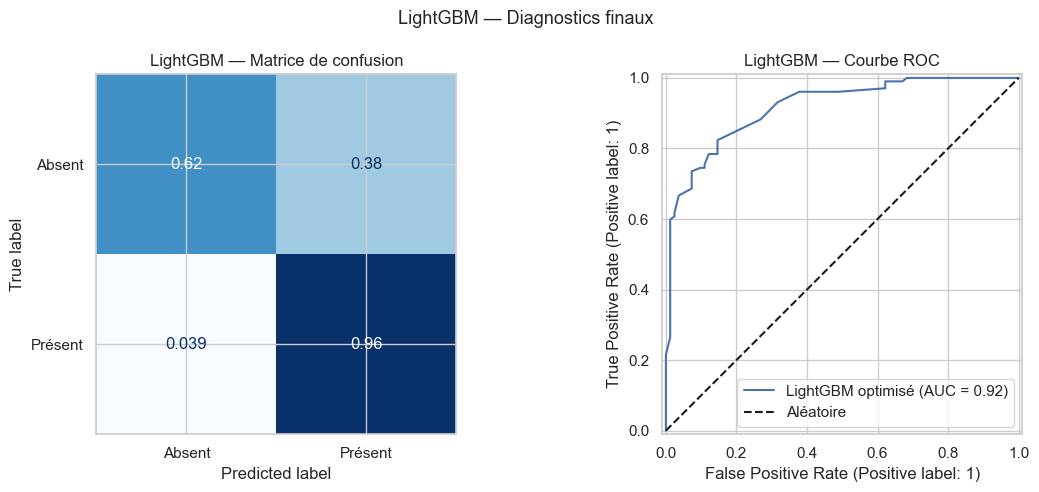

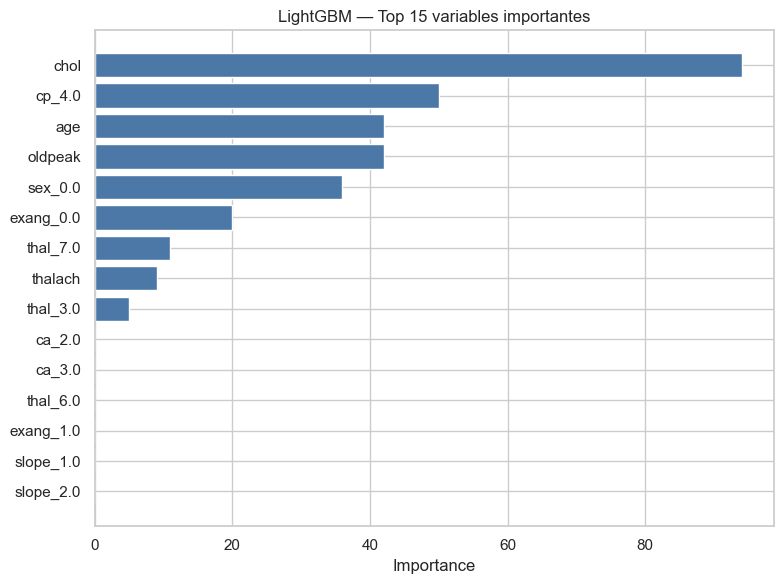

In [16]:
# ============================================================
# MODÈLE 9 — LIGHTGBM
# ============================================================


from lightgbm import LGBMClassifier

# --- Baseline ---
lgbm_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", LGBMClassifier(
        random_state=RANDOM_STATE,
        verbose=-1,
    )),
])

lgbm_pipeline.fit(X_train_bin, y_train_bin)

print("BASELINE — avant optimisation")

resultats_lgbm_baseline = evaluer_modele_binaire(
    lgbm_pipeline,
    X_test_bin,
    y_test_bin,
    nom_modele="LightGBM — Baseline"
)

# ============================================================
# OPTIMISATION
# ============================================================

lgbm_param_grid = {
    "modele__n_estimators":  [50, 100, 200],
    "modele__learning_rate": [0.01, 0.05, 0.1],
    "modele__max_depth":     [2, 3, 5, -1],
    "modele__num_leaves":    [15, 31, 63],
    "modele__subsample":     [0.8, 1.0],
    "modele__colsample_bytree": [0.8, 1.0],
}

lgbm_grid_search = GridSearchCV(
    lgbm_pipeline,
    lgbm_param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    refit=True,
)

lgbm_grid_search.fit(X_train_bin, y_train_bin)

print("\nMeilleurs hyperparamètres :")
print(f"  {lgbm_grid_search.best_params_}")
print(f"  Meilleur recall CV : {lgbm_grid_search.best_score_:.4f}")

print("\nAPRÈS OPTIMISATION")

resultats_lgbm = evaluer_modele_binaire(
    lgbm_grid_search.best_estimator_,
    X_test_bin,
    y_test_bin,
    nom_modele="LightGBM — Optimisé"
)

# ============================================================
# DIAGNOSTICS VISUELS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    lgbm_grid_search.best_estimator_,
    X_test_bin,
    y_test_bin,
    display_labels=["Absent", "Présent"],
    normalize="true",
    colorbar=False,
    cmap="Blues",
    ax=axes[0],
)

axes[0].set_title(
    "LightGBM — Matrice de confusion"
)

RocCurveDisplay.from_estimator(
    lgbm_grid_search.best_estimator_,
    X_test_bin,
    y_test_bin,
    ax=axes[1],
    name="LightGBM optimisé"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Aléatoire"
)

axes[1].set_title(
    "LightGBM — Courbe ROC"
)

axes[1].legend()

plt.suptitle(
    "LightGBM — Diagnostics finaux",
    fontsize=13
)

plt.tight_layout()
plt.show()

# ============================================================
# IMPORTANCE DES VARIABLES
# ============================================================

importances_lgbm = (
    lgbm_grid_search.best_estimator_
    .named_steps["modele"]
    .feature_importances_
)

ohe_features_lgbm = (
    lgbm_grid_search.best_estimator_
    .named_steps["preprocesseur"]
    .named_transformers_["categorielle"]
    .named_steps["encodage_ohe"]
    .get_feature_names_out(cat_features)
)

all_feature_names_lgbm = (
    num_features + list(ohe_features_lgbm)
)

fi_df_lgbm = (
    pd.DataFrame({
        "feature": all_feature_names_lgbm,
        "importance": importances_lgbm,
    })
    .sort_values("importance", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    fi_df_lgbm["feature"],
    fi_df_lgbm["importance"],
    color="#4C78A8"
)

ax.set_xlabel("Importance")

ax.set_title(
    "LightGBM — Top 15 variables importantes"
)

plt.tight_layout()
plt.show()

# ============================================================
# SAUVEGARDE
# ============================================================

lgbm_grid_search_bin = lgbm_grid_search

=== COMPARAISON FINALE — CLASSIFICATION BINAIRE ===



,modèle,recall,precision,f_beta_2,f1,roc_auc
0,Random Forest — Optimisé,0.9314,0.8482,0.9135,0.8879,0.9261
1,LightGBM — Optimisé,0.9608,0.7597,0.9125,0.8485,0.9170
2,XGBoost — Optimisé,0.9608,0.7538,0.9108,0.8448,0.9229
3,Extra Trees — Optimisé,0.9216,0.8319,0.9021,0.8744,0.9291
4,Gradient Boosting — Optimisé,0.9216,0.7899,0.8918,0.8507,0.9186
5,Decision Tree — Optimisé,0.8824,0.8036,0.8654,0.8411,0.8923
6,KNN — Optimisé,0.8725,0.8241,0.8624,0.8476,0.8870
7,Dummy Classifier (baseline),1.0000,0.5543,0.8615,0.7133,0.5000
8,Régression Logistique — Optimisée,0.8725,0.8018,0.8574,0.8357,0.8984


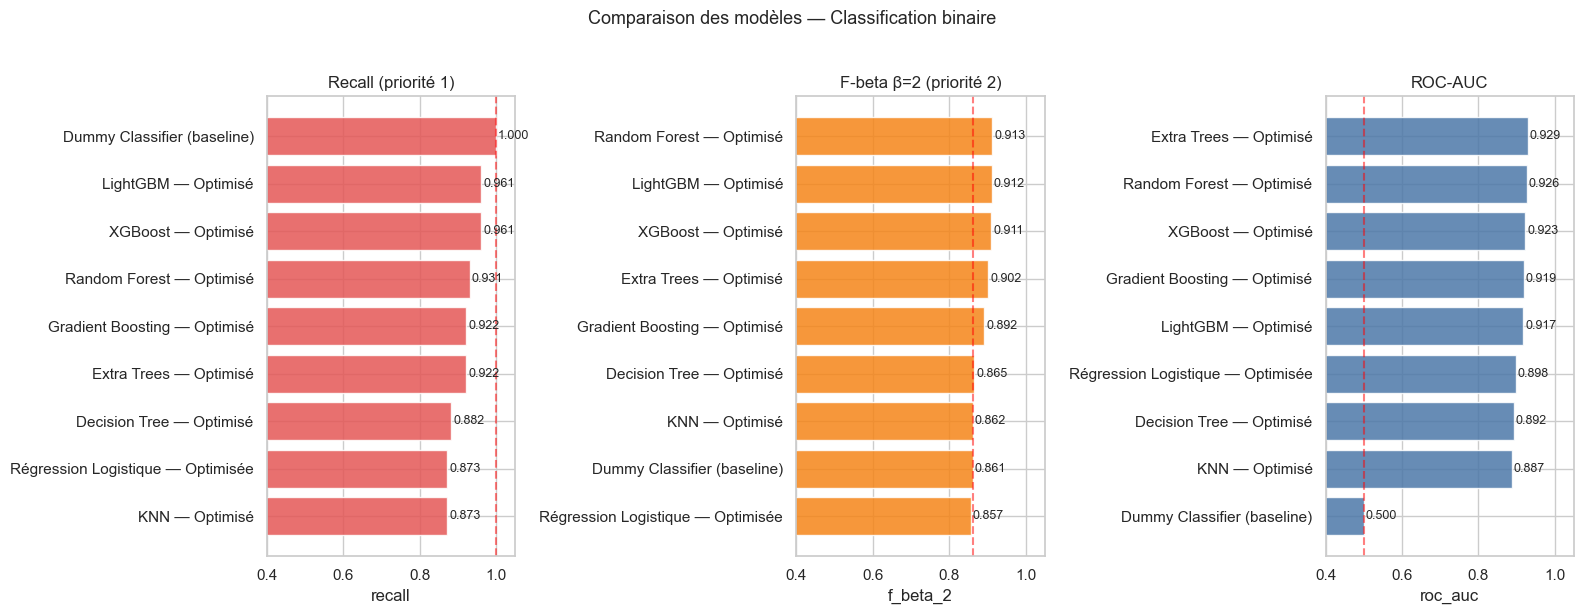

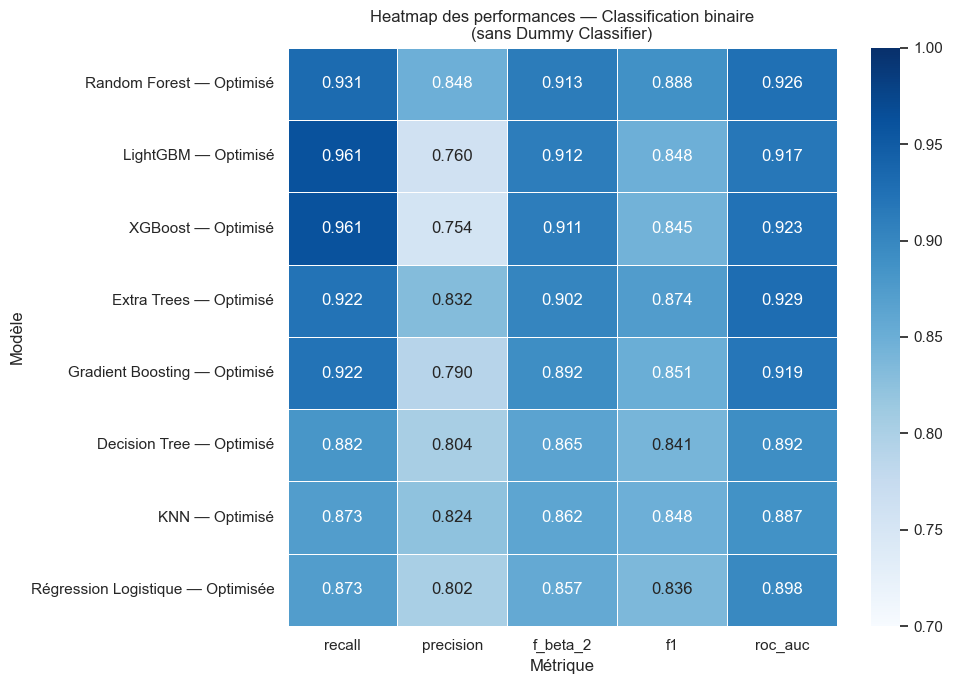

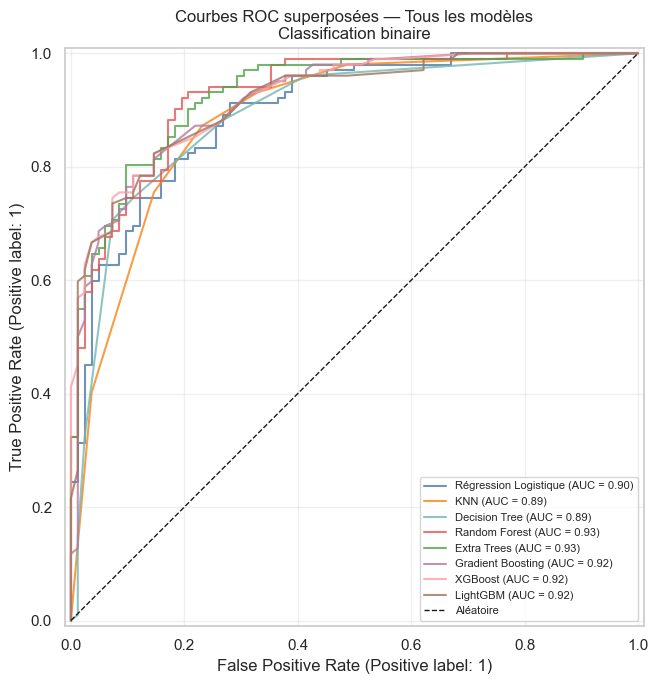


MODÈLE RETENU — Classification binaire
  Modèle    : Random Forest — Optimisé
  Recall    : 0.9314
  Precision : 0.8482
  F-beta(2) : 0.9135
  F1        : 0.8879
  ROC-AUC   : 0.9261

Justification : F-beta(β=2) retenu comme métrique principale
car en contexte médical, rater un malade (faux négatif)
est cliniquement plus grave que alarmer un sain (faux positif).
β=2 donne deux fois plus de poids au recall qu'à la precision.


In [17]:
# ============================================================
# COMPARAISON FINALE — TOUS LES MODÈLES BINAIRES
# ============================================================

# Collecte de tous les résultats optimisés
tous_resultats = [
    resultats_dummy,
    resultats_rl,
    resultats_knn,
    resultats_dt,
    resultats_rf,
    resultats_et,
    resultats_gbm,
    resultats_xgb,
    resultats_lgbm,
]

df_resultats = pd.DataFrame(tous_resultats)

# Tri par F-beta(2) décroissant — métrique prioritaire
df_resultats = df_resultats.sort_values(
    "f_beta_2", ascending=False
).reset_index(drop=True)

print("=== COMPARAISON FINALE — CLASSIFICATION BINAIRE ===\n")
display(df_resultats[[
    "modèle", "recall", "precision", "f_beta_2", "f1", "roc_auc"
]].round(4))

# ── Graphique 1 : barplot comparatif des métriques clés ──
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metriques = ["recall", "f_beta_2", "roc_auc"]
titres    = ["Recall (priorité 1)", "F-beta β=2 (priorité 2)", "ROC-AUC"]
couleurs  = ["#E45756", "#F58518", "#4C78A8"]

for ax, metrique, titre, couleur in zip(axes, metriques, titres, couleurs):
    df_plot = df_resultats.sort_values(metrique, ascending=True)
    bars = ax.barh(
        df_plot["modèle"], df_plot[metrique],
        color=couleur, alpha=0.85
    )
    ax.set_xlabel(metrique)
    ax.set_title(titre)
    ax.set_xlim(0.4, 1.05)
    # Annoter les valeurs
    for bar, val in zip(bars, df_plot[metrique]):
        ax.text(
            val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9
        )
    # Ligne de référence Dummy
    ax.axvline(
        x=df_resultats.loc[
            df_resultats["modèle"].str.contains("Dummy"), metrique
        ].values[0],
        color="red", linestyle="--", alpha=0.5, label="Dummy"
    )

plt.suptitle(
    "Comparaison des modèles — Classification binaire",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

# ── Graphique 2 : heatmap des métriques ──
df_heatmap = df_resultats.set_index("modèle")[[
    "recall", "precision", "f_beta_2", "f1", "roc_auc"
]].round(3)

# Exclure le Dummy pour la lisibilité
df_heatmap = df_heatmap[
    ~df_heatmap.index.str.contains("Dummy")
]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    df_heatmap,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
    vmin=0.7,
    vmax=1.0,
)
ax.set_title(
    "Heatmap des performances — Classification binaire\n"
    "(sans Dummy Classifier)",
    fontsize=12
)
ax.set_xlabel("Métrique")
ax.set_ylabel("Modèle")
plt.tight_layout()
plt.show()

# ── Graphique 3 : courbes ROC superposées ──
fig, ax = plt.subplots(figsize=(9, 7))

modeles_grid = {
    "Régression Logistique": rl_grid_search_bin,
    "KNN":                   knn_grid_search_bin,
    "Decision Tree":         dt_grid_search_bin,
    "Random Forest":         rf_grid_search_bin,
    "Extra Trees":           et_grid_search_bin,
    "Gradient Boosting":     gbm_grid_search_bin,
    "XGBoost":               xgb_grid_search_bin,
    "LightGBM":              lgbm_grid_search_bin,
}

couleurs_roc = [
    "#4C78A8", "#F58518", "#72B7B2", "#E45756",
    "#54A24B", "#B279A2", "#FF9DA6", "#9D755D"
]

for (nom, gs), couleur in zip(modeles_grid.items(), couleurs_roc):
    RocCurveDisplay.from_estimator(
        gs.best_estimator_,
        X_test_bin, y_test_bin,
        ax=ax,
        name=nom,
        color=couleur,
        alpha=0.8,
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire")
ax.set_title(
    "Courbes ROC superposées — Tous les modèles\n"
    "Classification binaire",
    fontsize=12
)
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMODÈLE RETENU — Classification binaire")
print("=" * 50)
meilleur = df_resultats.iloc[0]
print(f"  Modèle    : {meilleur['modèle']}")
print(f"  Recall    : {meilleur['recall']:.4f}")
print(f"  Precision : {meilleur['precision']:.4f}")
print(f"  F-beta(2) : {meilleur['f_beta_2']:.4f}")
print(f"  F1        : {meilleur['f1']:.4f}")
print(f"  ROC-AUC   : {meilleur['roc_auc']:.4f}")
print("\nJustification : F-beta(β=2) retenu comme métrique principale")
print("car en contexte médical, rater un malade (faux négatif)")
print("est cliniquement plus grave que alarmer un sain (faux positif).")
print("β=2 donne deux fois plus de poids au recall qu'à la precision.")

In [18]:
# ============================================================
# CLASSIFICATION MULTICLASSE — 0, 1, 2, 3+
# ============================================================
# On reprend exactement la même structure que le binaire.

def evaluer_modele_multiclasse(pipeline, X_test, y_test,
                                nom_modele):
    """
    Évalue un pipeline multiclasse sur le jeu de test.
    Retourne un dictionnaire de métriques macro.
    """
    noms_classes = ["Absent", "Léger", "Modéré", "Sévère"]

    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    # Binarisation pour l'AUC multiclasse
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

    resultats = {
        "modèle":    nom_modele,
        "recall":    recall_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "precision": precision_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "f_beta_2":  fbeta_score(
            y_test, y_pred, beta=2,
            average="macro", zero_division=0
        ),
        "f1_macro":  f1_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "roc_auc":   roc_auc_score(
            y_test_bin, y_proba,
            multi_class="ovr", average="macro"
        ),
        "accuracy":  accuracy_score(y_test, y_pred),
    }

    print(f"\n{'='*50}")
    print(f"  {nom_modele}")
    print(f"{'='*50}")
    print(classification_report(
        y_test, y_pred,
        target_names=noms_classes,
        zero_division=0
    ))
    print(f"  ROC-AUC macro : {resultats['roc_auc']:.4f}")
    print(f"  F-beta(2) mac : {resultats['f_beta_2']:.4f}")

    return resultats




  Dummy Classifier
              precision    recall  f1-score   support

      Absent       0.45      1.00      0.62        82
       Léger       0.00      0.00      0.00        53
      Modéré       0.00      0.00      0.00        22
      Sévère       0.00      0.00      0.00        27

    accuracy                           0.45       184
   macro avg       0.11      0.25      0.15       184
weighted avg       0.20      0.45      0.27       184

  ROC-AUC macro : 0.5000
  F-beta(2) mac : 0.2002

LogReg multiclasse — meilleurs params : {'modele__C': 0.01, 'modele__class_weight': 'balanced', 'modele__solver': 'lbfgs'}

  Régression Logistique — Optimisée
              precision    recall  f1-score   support

      Absent       0.83      0.78      0.81        82
       Léger       0.52      0.32      0.40        53
      Modéré       0.23      0.27      0.25        22
      Sévère       0.25      0.44      0.32        27

    accuracy                           0.54       184
   macro

,modèle,recall,precision,f_beta_2,f1_macro,roc_auc
0,XGBoost — Optimisé,0.5174,0.5361,0.5199,0.5246,0.7880
1,LightGBM — Optimisé,0.4906,0.4864,0.4891,0.4875,0.7966
2,Extra Trees — Optimisé,0.4962,0.4709,0.4876,0.4778,0.7889
3,Gradient Boosting — Optimisé,0.4603,0.4686,0.4600,0.4610,0.7902
4,Random Forest — Optimisé,0.4562,0.4475,0.4476,0.4422,0.8008
5,Régression Logistique — Optimisée,0.4546,0.4568,0.4462,0.4426,0.7843
6,KNN — Optimisé,0.4471,0.4371,0.4440,0.4404,0.7018
7,Decision Tree — Optimisé,0.4294,0.4444,0.4226,0.4226,0.7125
8,Dummy Classifier,0.2500,0.1114,0.2002,0.1541,0.5000


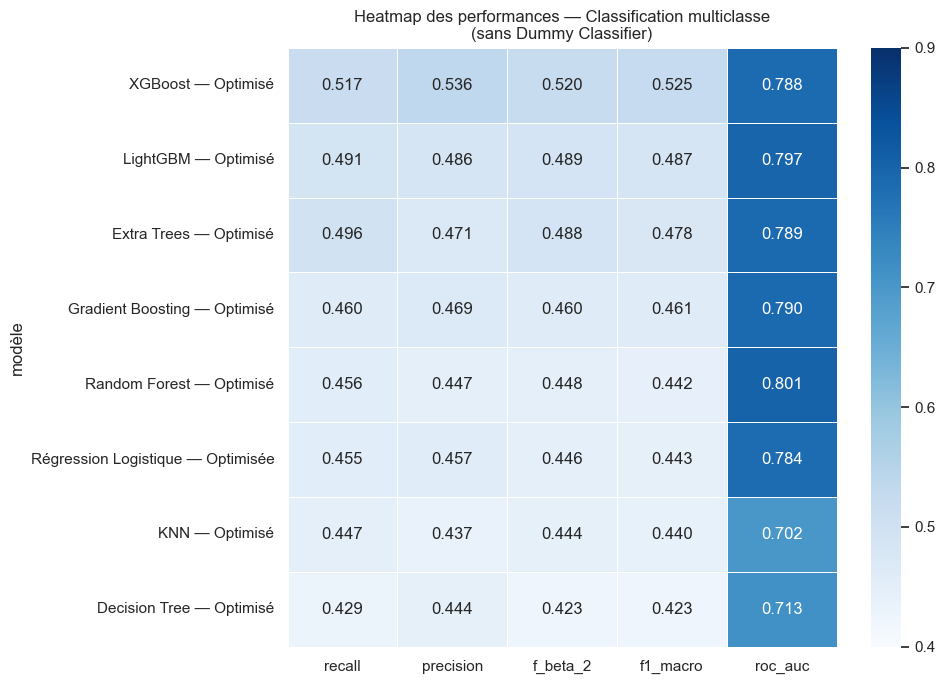

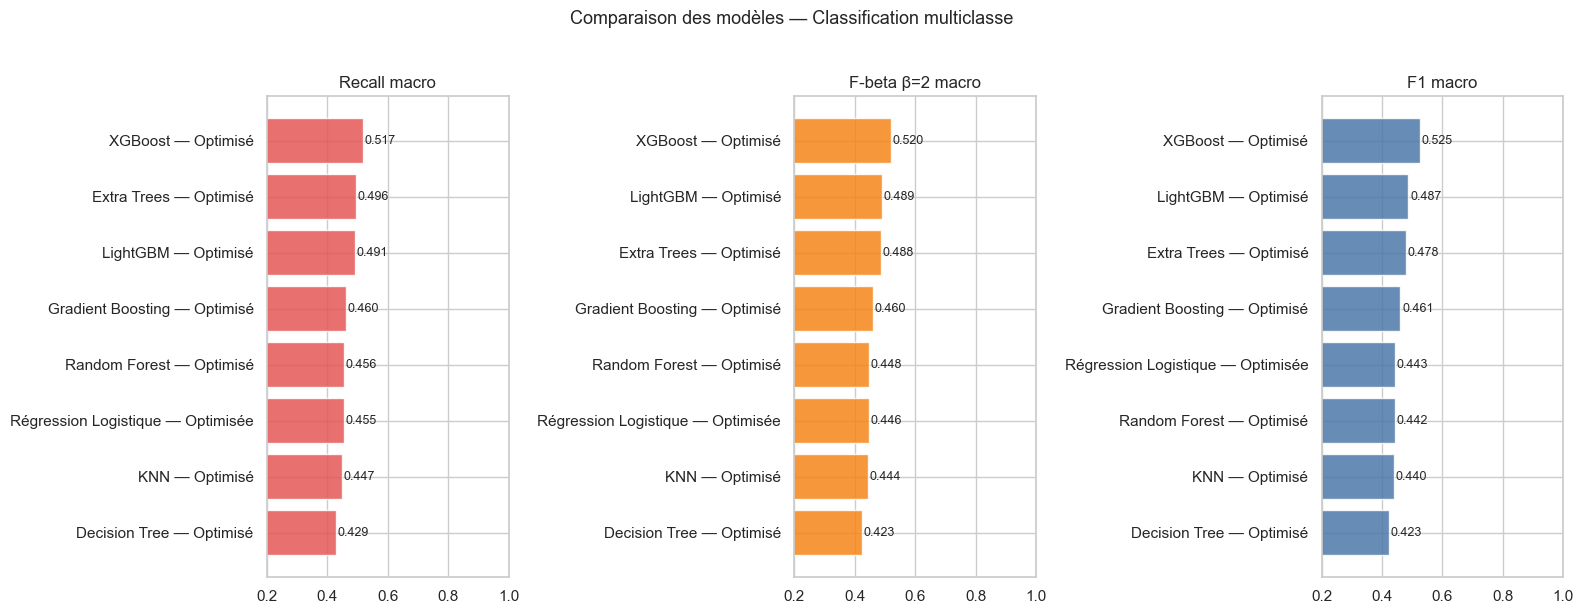

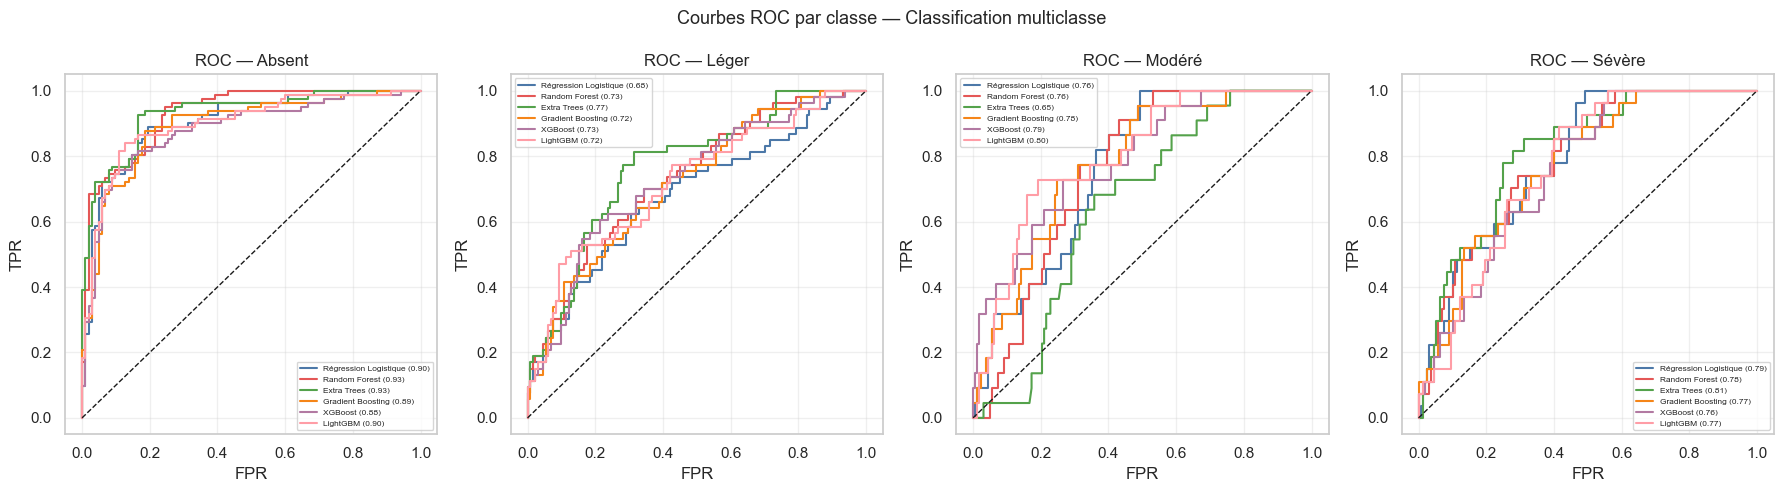


MODÈLE RETENU — Classification multiclasse
  Modèle    : XGBoost — Optimisé
  Recall    : 0.5174
  Precision : 0.5361
  F-beta(2) : 0.5199
  F1 macro  : 0.5246
  ROC-AUC   : 0.7880


In [19]:
# ============================================================
# CLASSIFICATION MULTICLASSE 
# ============================================================

def evaluer_modele_multiclasse(pipeline, X_test, y_test, nom_modele):
    noms_classes = ["Absent", "Léger", "Modéré", "Sévère"]
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

    resultats = {
        "modèle":    nom_modele,
        "recall":    recall_score(y_test, y_pred, average="macro", zero_division=0),
        "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "f_beta_2":  fbeta_score(y_test, y_pred, beta=2, average="macro", zero_division=0),
        "f1_macro":  f1_score(y_test, y_pred, average="macro", zero_division=0),
        "roc_auc":   roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="macro"),
        "accuracy":  accuracy_score(y_test, y_pred),
    }

    print(f"\n{'='*50}")
    print(f"  {nom_modele}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=noms_classes, zero_division=0))
    print(f"  ROC-AUC macro : {resultats['roc_auc']:.4f}")
    print(f"  F-beta(2) mac : {resultats['f_beta_2']:.4f}")
    return resultats


cv_mul = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# ── DUMMY ──────────────────────────────────────────────────
dummy_mul_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
])
dummy_mul_pipeline.fit(X_train_mul, y_train_mul)
res_dummy_mul = evaluer_modele_multiclasse(
    dummy_mul_pipeline, X_test_mul, y_test_mul, "Dummy Classifier"
)

# ── RÉGRESSION LOGISTIQUE ──────────────────────────────────
rl_mul_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
rl_mul_param_grid = {
    "modele__C":            [0.01, 0.1, 1, 5, 10],
    "modele__solver":       ["lbfgs", "saga"],
    "modele__class_weight": [None, "balanced"],
}
rl_mul_gs = GridSearchCV(
    rl_mul_pipeline, rl_mul_param_grid,
    cv=cv_mul, scoring="f1_macro", n_jobs=-1, refit=True
)
rl_mul_gs.fit(X_train_mul, y_train_mul)
print(f"\nLogReg multiclasse — meilleurs params : {rl_mul_gs.best_params_}")
res_rl_mul = evaluer_modele_multiclasse(
    rl_mul_gs.best_estimator_, X_test_mul, y_test_mul,
    "Régression Logistique — Optimisée"
)

# ── KNN ───────────────────────────────────────────────────
knn_mul_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", KNeighborsClassifier()),
])
knn_mul_param_grid = {
    "modele__n_neighbors": [3, 5, 7, 9, 11],
    "modele__weights":     ["uniform", "distance"],
    "modele__metric":      ["euclidean", "manhattan"],
}
knn_mul_gs = GridSearchCV(
    knn_mul_pipeline, knn_mul_param_grid,
    cv=cv_mul, scoring="f1_macro", n_jobs=-1, refit=True
)
knn_mul_gs.fit(X_train_mul, y_train_mul)
print(f"\nKNN multiclasse — meilleurs params : {knn_mul_gs.best_params_}")
res_knn_mul = evaluer_modele_multiclasse(
    knn_mul_gs.best_estimator_, X_test_mul, y_test_mul,
    "KNN — Optimisé"
)

# ── DECISION TREE ──────────────────────────────────────────
dt_mul_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])
dt_mul_param_grid = {
    "modele__max_depth":         [3, 5, 7, 10, None],
    "modele__min_samples_split": [2, 5, 10, 20],
    "modele__min_samples_leaf":  [1, 2, 5],
    "modele__criterion":         ["gini", "entropy"],
    "modele__class_weight":      [None, "balanced"],
}
dt_mul_gs = GridSearchCV(
    dt_mul_pipeline, dt_mul_param_grid,
    cv=cv_mul, scoring="f1_macro", n_jobs=-1, refit=True
)
dt_mul_gs.fit(X_train_mul, y_train_mul)
print(f"\nDecision Tree multiclasse — meilleurs params : {dt_mul_gs.best_params_}")
res_dt_mul = evaluer_modele_multiclasse(
    dt_mul_gs.best_estimator_, X_test_mul, y_test_mul,
    "Decision Tree — Optimisé"
)

# ── RANDOM FOREST ──────────────────────────────────────────
rf_mul_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", RandomForestClassifier(random_state=RANDOM_STATE)),
])
rf_mul_param_grid = {
    "modele__n_estimators":      [100, 200, 300],
    "modele__max_depth":         [None, 5, 10, 15],
    "modele__min_samples_split": [2, 5, 10],
    "modele__max_features":      ["sqrt", "log2"],
    "modele__class_weight":      [None, "balanced"],
}
rf_mul_gs = GridSearchCV(
    rf_mul_pipeline, rf_mul_param_grid,
    cv=cv_mul, scoring="f1_macro", n_jobs=-1, refit=True
)
rf_mul_gs.fit(X_train_mul, y_train_mul)
print(f"\nRandom Forest multiclasse — meilleurs params : {rf_mul_gs.best_params_}")
res_rf_mul = evaluer_modele_multiclasse(
    rf_mul_gs.best_estimator_, X_test_mul, y_test_mul,
    "Random Forest — Optimisé"
)

# ── EXTRA TREES ────────────────────────────────────────────
et_mul_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", ExtraTreesClassifier(random_state=RANDOM_STATE)),
])
et_mul_param_grid = {
    "modele__n_estimators":      [100, 200, 300],
    "modele__max_depth":         [None, 5, 10, 15],
    "modele__min_samples_split": [2, 5, 10],
    "modele__max_features":      ["sqrt", "log2"],
    "modele__class_weight":      [None, "balanced"],
}
et_mul_gs = GridSearchCV(
    et_mul_pipeline, et_mul_param_grid,
    cv=cv_mul, scoring="f1_macro", n_jobs=-1, refit=True
)
et_mul_gs.fit(X_train_mul, y_train_mul)
print(f"\nExtra Trees multiclasse — meilleurs params : {et_mul_gs.best_params_}")
res_et_mul = evaluer_modele_multiclasse(
    et_mul_gs.best_estimator_, X_test_mul, y_test_mul,
    "Extra Trees — Optimisé"
)

# ── GRADIENT BOOSTING ──────────────────────────────────────
gbm_mul_pipeline = Pipeline(steps=[
    ("preprocesseur", preprocessor),
    ("modele", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])
gbm_mul_param_grid = {
    "modele__n_estimators":      [50, 100, 200],
    "modele__learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "modele__max_depth":         [3, 5, 7],
    "modele__subsample":         [0.8, 1.0],
    "modele__min_samples_split": [2, 5],
}
gbm_mul_gs = GridSearchCV(
    gbm_mul_pipeline, gbm_mul_param_grid,
    cv=cv_mul, scoring="f1_macro", n_jobs=-1, refit=True
)
gbm_mul_gs.fit(X_train_mul, y_train_mul)
print(f"\nGBM multiclasse — meilleurs params : {gbm_mul_gs.best_params_}")
res_gbm_mul = evaluer_modele_multiclasse(
    gbm_mul_gs.best_estimator_, X_test_mul, y_test_mul,
    "Gradient Boosting — Optimisé"
)

# ── XGBOOST ────────────────────────────────────────────────
if HAS_XGB:
    xgb_mul_pipeline = Pipeline(steps=[
        ("preprocesseur", preprocessor),
        ("modele", XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            use_label_encoder=False,
            random_state=RANDOM_STATE,
        )),
    ])
    xgb_mul_param_grid = {
        "modele__n_estimators":   [50, 100, 200],
        "modele__learning_rate":  [0.01, 0.05, 0.1],
        "modele__max_depth":      [3, 5, 7],
        "modele__subsample":      [0.8, 1.0],
        "modele__colsample_bytree": [0.8, 1.0],
    }
    xgb_mul_gs = GridSearchCV(
        xgb_mul_pipeline, xgb_mul_param_grid,
        cv=cv_mul, scoring="f1_macro", n_jobs=-1, refit=True
    )
    xgb_mul_gs.fit(X_train_mul, y_train_mul)
    print(f"\nXGBoost multiclasse — meilleurs params : {xgb_mul_gs.best_params_}")
    res_xgb_mul = evaluer_modele_multiclasse(
        xgb_mul_gs.best_estimator_, X_test_mul, y_test_mul,
        "XGBoost — Optimisé"
    )

# ── LIGHTGBM ─────────────────────────────────────────────
if HAS_LGBM:
    lgbm_mul_pipeline = Pipeline(steps=[
        ("preprocesseur", preprocessor),
        ("modele", LGBMClassifier(
            objective="multiclass",
            random_state=RANDOM_STATE,
            verbose=-1,
        )),
    ])
    lgbm_mul_param_grid = {
        "modele__n_estimators":    [50, 100, 200],
        "modele__learning_rate":   [0.01, 0.05, 0.1],
        "modele__max_depth":       [3, 5, 7],
        "modele__num_leaves":      [15, 31, 63],
        "modele__subsample":       [0.8, 1.0],
        "modele__colsample_bytree": [0.8, 1.0],
    }
    lgbm_mul_gs = GridSearchCV(
        lgbm_mul_pipeline, lgbm_mul_param_grid,
        cv=cv_mul, scoring="f1_macro", n_jobs=-1, refit=True
    )
    lgbm_mul_gs.fit(X_train_mul, y_train_mul)
    print(f"\nLightGBM multiclasse — meilleurs params : {lgbm_mul_gs.best_params_}")
    res_lgbm_mul = evaluer_modele_multiclasse(
        lgbm_mul_gs.best_estimator_, X_test_mul, y_test_mul,
        "LightGBM — Optimisé"
    )

# ============================================================
# COMPARAISON FINALE MULTICLASSE
# ============================================================
tous_resultats_mul = [
    res_dummy_mul, res_rl_mul, res_knn_mul, res_dt_mul,
    res_rf_mul, res_et_mul, res_gbm_mul,
]
if HAS_XGB:
    tous_resultats_mul.append(res_xgb_mul)
if HAS_LGBM:
    tous_resultats_mul.append(res_lgbm_mul)

df_resultats_mul = pd.DataFrame(tous_resultats_mul).sort_values(
    "f_beta_2", ascending=False
).reset_index(drop=True)

print("\n=== COMPARAISON FINALE — CLASSIFICATION MULTICLASSE ===\n")
display(df_resultats_mul[[
    "modèle", "recall", "precision", "f_beta_2", "f1_macro", "roc_auc"
]].round(4))

# Heatmap
df_heatmap_mul = df_resultats_mul.set_index("modèle")[[
    "recall", "precision", "f_beta_2", "f1_macro", "roc_auc"
]].round(3)
df_heatmap_mul = df_heatmap_mul[~df_heatmap_mul.index.str.contains("Dummy")]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    df_heatmap_mul, annot=True, fmt=".3f",
    cmap="Blues", linewidths=0.5, ax=ax,
    vmin=0.4, vmax=0.9,
)
ax.set_title(
    "Heatmap des performances — Classification multiclasse\n"
    "(sans Dummy Classifier)", fontsize=12
)
plt.tight_layout()
plt.show()

# Barplots comparatifs
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metriques  = ["recall", "f_beta_2", "f1_macro"]
titres     = ["Recall macro", "F-beta β=2 macro", "F1 macro"]
couleurs   = ["#E45756", "#F58518", "#4C78A8"]

for ax, metrique, titre, couleur in zip(axes, metriques, titres, couleurs):
    df_plot = df_resultats_mul[
        ~df_resultats_mul["modèle"].str.contains("Dummy")
    ].sort_values(metrique, ascending=True)
    bars = ax.barh(df_plot["modèle"], df_plot[metrique],
                   color=couleur, alpha=0.85)
    ax.set_title(titre)
    ax.set_xlim(0.2, 1.0)
    for bar, val in zip(bars, df_plot[metrique]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)

plt.suptitle(
    "Comparaison des modèles — Classification multiclasse",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

# Courbes ROC multiclasse superposées
noms_classes = ["Absent", "Léger", "Modéré", "Sévère"]
y_test_bin_mul = label_binarize(y_test_mul, classes=[0, 1, 2, 3])

modeles_mul_grid = {
    "Régression Logistique": rl_mul_gs,
    "Random Forest":         rf_mul_gs,
    "Extra Trees":           et_mul_gs,
    "Gradient Boosting":     gbm_mul_gs,
}
if HAS_XGB:
    modeles_mul_grid["XGBoost"] = xgb_mul_gs
if HAS_LGBM:
    modeles_mul_grid["LightGBM"] = lgbm_mul_gs

couleurs_mul = ["#4C78A8", "#E45756", "#54A24B",
                "#F58518", "#B279A2", "#FF9DA6"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for idx, (classe_idx, classe_nom) in enumerate(
    zip([0, 1, 2, 3], noms_classes)
):
    ax = axes[idx]
    for (nom, gs), couleur in zip(
        modeles_mul_grid.items(), couleurs_mul
    ):
        y_proba = gs.best_estimator_.predict_proba(X_test_mul)
        fpr, tpr, _ = roc_curve(
            y_test_bin_mul[:, classe_idx], y_proba[:, classe_idx]
        )
        auc_val = roc_auc_score(
            y_test_bin_mul[:, classe_idx], y_proba[:, classe_idx]
        )
        ax.plot(fpr, tpr, color=couleur, lw=1.5,
                label=f"{nom} ({auc_val:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"ROC — {classe_nom}")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Courbes ROC par classe — Classification multiclasse",
    fontsize=13
)
plt.tight_layout()
plt.show()

# Modèle retenu
meilleur_mul = df_resultats_mul.iloc[0]
print("\nMODÈLE RETENU — Classification multiclasse")
print("=" * 50)
print(f"  Modèle    : {meilleur_mul['modèle']}")
print(f"  Recall    : {meilleur_mul['recall']:.4f}")
print(f"  Precision : {meilleur_mul['precision']:.4f}")
print(f"  F-beta(2) : {meilleur_mul['f_beta_2']:.4f}")
print(f"  F1 macro  : {meilleur_mul['f1_macro']:.4f}")
print(f"  ROC-AUC   : {meilleur_mul['roc_auc']:.4f}")

MODÈLE BINAIRE RETENU
  Modèle    : Random Forest — Optimisé
  Recall    : 0.9314
  Precision : 0.8482
  F-beta(2) : 0.9135
  F1        : 0.8879
  ROC-AUC   : 0.9261

Impact du seuil de décision sur les métriques


,seuil,recall,precision,f1,FN,FP
0,0.2000,0.9900,0.6920,0.8150,1,45
1,0.2500,0.9900,0.7210,0.8350,1,39
2,0.3000,0.9900,0.7540,0.8560,1,33
3,0.3500,0.9800,0.7630,0.8580,2,31
4,0.4000,0.9410,0.7870,0.8570,6,26
5,0.4500,0.9310,0.8260,0.8760,7,20
6,0.5000,0.9310,0.8480,0.8880,7,17
7,0.5500,0.8920,0.8580,0.8750,11,15
8,0.6000,0.8430,0.8600,0.8510,16,14
9,0.6500,0.7840,0.8600,0.8210,22,13



Plancher de précision appliqué : 0.798
Seuil retenu                   : 0.45

Comparaison seuil 0.50 → seuil retenu (0.45)
  Recall    : 0.931  →  0.931
  Precision : 0.848  →  0.826
  F1        : 0.888  →  0.876
  FN (malades ratés) : 7  →  7
  FP (sains alarmés) : 17  →  20


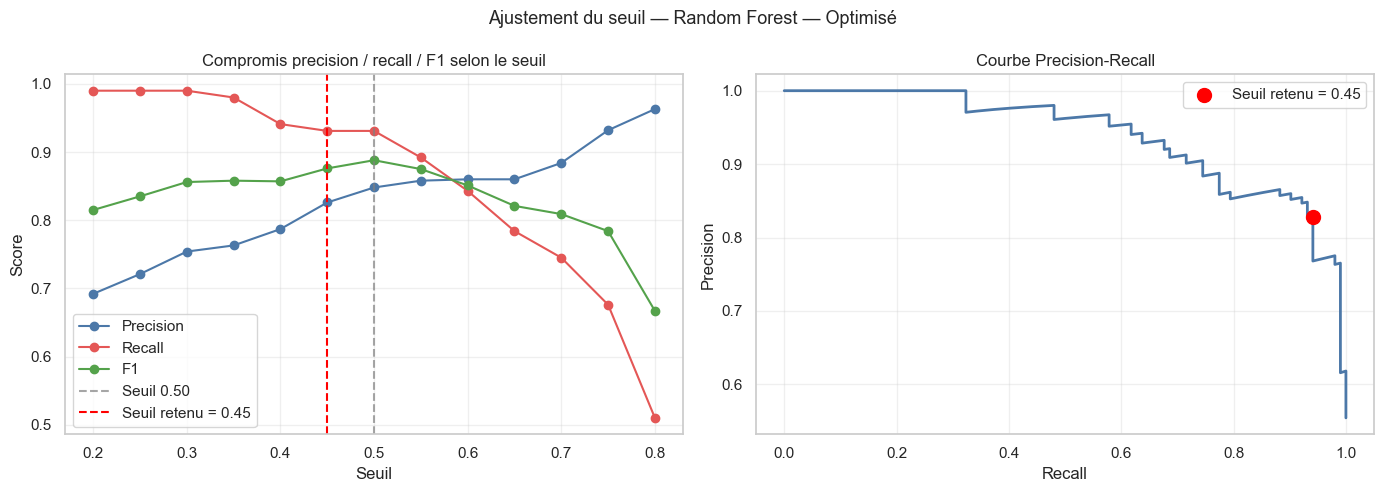

In [20]:
# ============================================================
# MODÈLE BINAIRE RETENU — SÉLECTION ET AJUSTEMENT DU SEUIL
# ============================================================

from sklearn.metrics import precision_recall_curve  # import manquant

# --- Identification du meilleur modèle binaire ---
meilleur_bin = df_resultats.iloc[0]

print("MODÈLE BINAIRE RETENU")
print("=" * 50)
print(f"  Modèle    : {meilleur_bin['modèle']}")
print(f"  Recall    : {meilleur_bin['recall']:.4f}")
print(f"  Precision : {meilleur_bin['precision']:.4f}")
print(f"  F-beta(2) : {meilleur_bin['f_beta_2']:.4f}")
print(f"  F1        : {meilleur_bin['f1']:.4f}")
print(f"  ROC-AUC   : {meilleur_bin['roc_auc']:.4f}")

# --- Récupération du pipeline retenu ---
pipelines_bin = {
    "Régression Logistique — Optimisée": rl_grid_search_bin,
    "KNN — Optimisé":                    knn_grid_search_bin,
    "Decision Tree — Optimisé":          dt_grid_search_bin,
    "Random Forest — Optimisé":          rf_grid_search_bin,
    "Extra Trees — Optimisé":            et_grid_search_bin,
    "Gradient Boosting — Optimisé":      gbm_grid_search_bin,
    "XGBoost — Optimisé":                xgb_grid_search_bin,
    "LightGBM — Optimisé":               lgbm_grid_search_bin,
}

nom_retenu      = meilleur_bin["modèle"]
pipeline_retenu = pipelines_bin[nom_retenu].best_estimator_

# Probabilités d'être malade sur le jeu de test
y_proba_retenu = pipeline_retenu.predict_proba(X_test_bin)[:, 1]

# ============================================================
# EXPLORATION DES SEUILS DE 0.20 à 0.80
# ============================================================

seuils = np.arange(0.20, 0.81, 0.05)
lignes = []

for seuil in seuils:
    y_pred_seuil = (y_proba_retenu >= seuil).astype(int)
    rec  = recall_score(y_test_bin, y_pred_seuil, zero_division=0)
    prec = precision_score(y_test_bin, y_pred_seuil, zero_division=0)
    f1   = f1_score(y_test_bin, y_pred_seuil, zero_division=0)
    cm   = confusion_matrix(y_test_bin, y_pred_seuil)
    fn   = cm[1, 0] if cm.shape == (2, 2) else 0
    fp   = cm[0, 1] if cm.shape == (2, 2) else 0
    lignes.append({
        "seuil":     round(seuil, 2),
        "recall":    round(rec,  3),
        "precision": round(prec, 3),
        "f1":        round(f1,   3),
        "FN":        fn,
        "FP":        fp,
    })

df_seuils = pd.DataFrame(lignes)

print("\nImpact du seuil de décision sur les métriques")
print("=" * 55)
display(df_seuils)

# ============================================================
# SÉLECTION DU SEUIL RETENU
# ============================================================
# Critère principal  : maximiser le recall (détecter les malades)
# Contrainte         : precision >= precision_défaut - 0.05
# Départage          : minimiser les FN (malades ratés)
# ============================================================

precision_defaut  = df_seuils.loc[df_seuils["seuil"] == 0.50, "precision"].values[0]
plancher_precision = max(0.60, precision_defaut - 0.05)

eligibles    = df_seuils[df_seuils["precision"] >= plancher_precision].copy()

# Tri : recall décroissant, puis FN croissant pour départager
seuil_retenu = eligibles.sort_values(
    ["recall", "FN"], ascending=[False, True]
).iloc[0]["seuil"]

row_retenu = df_seuils[df_seuils["seuil"] == seuil_retenu].iloc[0]
row_defaut = df_seuils[df_seuils["seuil"] == 0.50].iloc[0]

print(f"\nPlancher de précision appliqué : {plancher_precision:.3f}")
print(f"Seuil retenu                   : {seuil_retenu}")

print(f"\nComparaison seuil 0.50 → seuil retenu ({seuil_retenu})")
print(f"  Recall    : {row_defaut['recall']:.3f}  →  {row_retenu['recall']:.3f}")
print(f"  Precision : {row_defaut['precision']:.3f}  →  {row_retenu['precision']:.3f}")
print(f"  F1        : {row_defaut['f1']:.3f}  →  {row_retenu['f1']:.3f}")
print(f"  FN (malades ratés) : {int(row_defaut['FN'])}  →  {int(row_retenu['FN'])}")
print(f"  FP (sains alarmés) : {int(row_defaut['FP'])}  →  {int(row_retenu['FP'])}")

# ============================================================
# VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 — Precision / Recall / F1 selon le seuil
ax = axes[0]
ax.plot(df_seuils["seuil"], df_seuils["precision"],
        marker="o", label="Precision", color="#4C78A8")
ax.plot(df_seuils["seuil"], df_seuils["recall"],
        marker="o", label="Recall",    color="#E45756")
ax.plot(df_seuils["seuil"], df_seuils["f1"],
        marker="o", label="F1",        color="#54A24B")
ax.axvline(x=0.50, color="gray",  linestyle="--",
           label="Seuil 0.50", alpha=0.7)
ax.axvline(x=seuil_retenu, color="red", linestyle="--",
           label=f"Seuil retenu = {seuil_retenu}")
ax.set_xlabel("Seuil")
ax.set_ylabel("Score")
ax.set_title("Compromis precision / recall / F1 selon le seuil")
ax.legend()
ax.grid(True, alpha=0.3)

# Graphique 2 — Courbe Precision-Recall avec point retenu
precisions_courbe, recalls_courbe, seuils_courbe = precision_recall_curve(
    y_test_bin, y_proba_retenu
)
ax2 = axes[1]
ax2.plot(recalls_courbe, precisions_courbe,
         color="#4C78A8", lw=2)
idx_proche = np.argmin(np.abs(seuils_courbe - seuil_retenu))
ax2.scatter(
    recalls_courbe[idx_proche],
    precisions_courbe[idx_proche],
    color="red", s=100, zorder=5,
    label=f"Seuil retenu = {seuil_retenu}"
)
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Courbe Precision-Recall")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f"Ajustement du seuil — {nom_retenu}",
    fontsize=13
)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# SAUVEGARDE DES MODÈLES — Binaire et Multiclasse
# ============================================================

import joblib
import json
import os

# Dossier principal
base_dir        = os.path.join(os.getcwd(), "enregistrement_modeles")
dir_binaire     = os.path.join(base_dir, "binaire")
dir_multiclasse = os.path.join(base_dir, "multiclasse")

os.makedirs(dir_binaire,     exist_ok=True)
os.makedirs(dir_multiclasse, exist_ok=True)

# ============================================================
# BINAIRE — tous les modèles optimisés
# ============================================================

modeles_binaire = {
    "logistic_regression": rl_grid_search_bin.best_estimator_,
    "knn":                 knn_grid_search_bin.best_estimator_,
    "decision_tree":       dt_grid_search_bin.best_estimator_,
    "random_forest":       rf_grid_search_bin.best_estimator_,
    "extra_trees":         et_grid_search_bin.best_estimator_,
    "gradient_boosting":   gbm_grid_search_bin.best_estimator_,
    "xgboost":             xgb_grid_search_bin.best_estimator_,
    "lightgbm":            lgbm_grid_search_bin.best_estimator_,
}

print("=== SAUVEGARDE BINAIRE ===")
for nom, pipeline in modeles_binaire.items():
    chemin = os.path.join(dir_binaire, f"{nom}.pkl")
    joblib.dump(pipeline, chemin)
    print(f"  Sauvegardé : {nom}.pkl")

# Meilleur modèle binaire — fichier dupliqué avec nom explicite
# nom_retenu vient de la cellule d'ajustement du seuil
meilleur_pipeline_bin = pipelines_bin[nom_retenu].best_estimator_
chemin_meilleur_bin   = os.path.join(dir_binaire, "MEILLEUR_MODELE_BINAIRE.pkl")
joblib.dump(meilleur_pipeline_bin, chemin_meilleur_bin)
print(f"\n  Meilleur modèle binaire : {nom_retenu}")
print(f"  Sauvegardé aussi sous   : MEILLEUR_MODELE_BINAIRE.pkl")

# Seuil retenu — sauvegardé dans un fichier JSON
# seuil_retenu et row_retenu viennent de la cellule d'ajustement
infos_seuil = {
    "modele_retenu":          nom_retenu,
    "seuil_retenu":           float(seuil_retenu),
    "seuil_defaut":           0.50,
    "recall_seuil_retenu":    float(row_retenu["recall"]),
    "precision_seuil_retenu": float(row_retenu["precision"]),
    "f1_seuil_retenu":        float(row_retenu["f1"]),
    "FN_seuil_retenu":        int(row_retenu["FN"]),
    "FP_seuil_retenu":        int(row_retenu["FP"]),
}
with open(os.path.join(dir_binaire, "seuil_retenu.json"), "w") as f:
    json.dump(infos_seuil, f, indent=2)
print(f"  Seuil retenu sauvegardé : {seuil_retenu}")

# ============================================================
# MULTICLASSE — tous les modèles optimisés
# ============================================================
# Les variables suivantes viennent de la cellule 17 :
# rl_mul_gs, knn_mul_gs, dt_mul_gs, rf_mul_gs,
# et_mul_gs, gbm_mul_gs, xgb_mul_gs, lgbm_mul_gs
# df_resultats_mul contient le classement final multiclasse
# ============================================================

print("\n=== SAUVEGARDE MULTICLASSE ===")

modeles_multiclasse = {
    "logistic_regression": rl_mul_gs.best_estimator_,
    "knn":                 knn_mul_gs.best_estimator_,
    "decision_tree":       dt_mul_gs.best_estimator_,
    "random_forest":       rf_mul_gs.best_estimator_,
    "extra_trees":         et_mul_gs.best_estimator_,
    "gradient_boosting":   gbm_mul_gs.best_estimator_,
}
if HAS_XGB:
    modeles_multiclasse["xgboost"]  = xgb_mul_gs.best_estimator_
if HAS_LGBM:
    modeles_multiclasse["lightgbm"] = lgbm_mul_gs.best_estimator_

for nom, pipeline in modeles_multiclasse.items():
    chemin = os.path.join(dir_multiclasse, f"{nom}.pkl")
    joblib.dump(pipeline, chemin)
    print(f"  Sauvegardé : {nom}.pkl")

# Meilleur modèle multiclasse — identifié via df_resultats_mul
# df_resultats_mul est trié par f_beta_2 décroissant
nom_retenu_mul = df_resultats_mul.iloc[0]["modèle"]

# Correspondance nom affiché → clé du dictionnaire
correspondance_mul = {
    "Régression Logistique — Optimisée": "logistic_regression",
    "KNN — Optimisé":                    "knn",
    "Decision Tree — Optimisé":          "decision_tree",
    "Random Forest — Optimisé":          "random_forest",
    "Extra Trees — Optimisé":            "extra_trees",
    "Gradient Boosting — Optimisé":      "gradient_boosting",
    "XGBoost — Optimisé":                "xgboost",
    "LightGBM — Optimisé":               "lightgbm",
}

cle_retenu_mul    = correspondance_mul.get(nom_retenu_mul, "random_forest")
meilleur_pipeline_mul = modeles_multiclasse[cle_retenu_mul]

chemin_meilleur_mul = os.path.join(
    dir_multiclasse, "MEILLEUR_MODELE_MULTICLASSE.pkl"
)
joblib.dump(meilleur_pipeline_mul, chemin_meilleur_mul)
print(f"\n  Meilleur modèle multiclasse : {nom_retenu_mul}")
print(f"  Sauvegardé aussi sous       : MEILLEUR_MODELE_MULTICLASSE.pkl")

# Mapping des classes
mapping_classes = {
    "0": "Absent",
    "1": "Léger",
    "2": "Modéré",
    "3": "Sévère (3+4 fusionnés)",
}
with open(os.path.join(dir_multiclasse, "mapping_classes.json"),
          "w", encoding="utf-8") as f:
    json.dump(mapping_classes, f, indent=2, ensure_ascii=False)
print("  Mapping des classes sauvegardé")

# ============================================================
# INFOS GÉNÉRALES — features, paramètres, cibles
# ============================================================

infos_generales = {
    "features":     features,
    "num_features": num_features,
    "cat_features": cat_features,
    "random_state": RANDOM_STATE,
    "test_size":    TEST_SIZE,
    "cv_folds":     CV_FOLDS,
    "cible_binaire": {
        "0": "Absent",
        "1": "Présent"
    },
    "cible_multiclasse": {
        "0": "Absent",
        "1": "Léger",
        "2": "Modéré",
        "3": "Sévère (3+4 fusionnés)"
    },
    "meilleur_modele_binaire":     nom_retenu,
    "meilleur_modele_multiclasse": nom_retenu_mul,
}
with open(os.path.join(base_dir, "infos_modeles.json"),
          "w", encoding="utf-8") as f:
    json.dump(infos_generales, f, indent=2, ensure_ascii=False)
print("\n  Infos générales sauvegardées : infos_modeles.json")

# ============================================================
# VÉRIFICATION — liste tous les fichiers sauvegardés
# ============================================================

print("\n\nCONTENU DU DOSSIER enregistrement_modeles")
print("=" * 55)
for root, dirs, files in os.walk(base_dir):
    niveau = root.replace(base_dir, "").count(os.sep)
    indent = "  " * niveau
    print(f"{indent}{os.path.basename(root)}/")
    for fichier in sorted(files):
        taille = os.path.getsize(os.path.join(root, fichier))
        print(f"{indent}  {fichier}  ({taille/1024:.1f} Ko)")

=== SAUVEGARDE BINAIRE ===
  Sauvegardé : logistic_regression.pkl
  Sauvegardé : knn.pkl
  Sauvegardé : decision_tree.pkl
  Sauvegardé : random_forest.pkl
  Sauvegardé : extra_trees.pkl
  Sauvegardé : gradient_boosting.pkl
  Sauvegardé : xgboost.pkl
  Sauvegardé : lightgbm.pkl

  Meilleur modèle binaire : Random Forest — Optimisé
  Sauvegardé aussi sous   : MEILLEUR_MODELE_BINAIRE.pkl
  Seuil retenu sauvegardé : 0.45

=== SAUVEGARDE MULTICLASSE ===
  Sauvegardé : logistic_regression.pkl
  Sauvegardé : knn.pkl
  Sauvegardé : decision_tree.pkl
  Sauvegardé : random_forest.pkl
  Sauvegardé : extra_trees.pkl
  Sauvegardé : gradient_boosting.pkl
  Sauvegardé : xgboost.pkl
  Sauvegardé : lightgbm.pkl

  Meilleur modèle multiclasse : XGBoost — Optimisé
  Sauvegardé aussi sous       : MEILLEUR_MODELE_MULTICLASSE.pkl
  Mapping des classes sauvegardé

  Infos générales sauvegardées : infos_modeles.json


CONTENU DU DOSSIER enregistrement_modeles
enregistrement_modeles/
  infos_modeles.json  (0.8